# Power-sweep TLS saturation analysis

This notebook uses the original empirical power-sweep fit:

\[
rac{1}{Q_i(n)} = C_j^{P} + A_{m TLS,s}^{P}\,rac{	anh(h f_j/2 k_B T)}{\sqrt{1+(n/n_{c,s})^{eta}}}.
\]

Here the high-power offset/floor \(C_j^P\) is fit independently for each resonator, while \(A_{m TLS,s}^P\) and \(n_{c,s}\) are shared within a sample/wafer. This is intended as an empirical characterization of TLS saturation, not as a hard-constrained validation of the temperature-fit nuisance parameters.




In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import lsq_linear
from scipy import special

# Add the parent directory path to the system path
import sys
sys.path.append("../..")

# Optional display helper for notebooks
try:
    from IPython.display import display
except Exception:
    display = print

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
from FilmStressed.data.curated_data import data_dict as stress_resonators

# Drop Sample N if present
stress_resonators = dict(stress_resonators)
stress_resonators.pop("Sample N", None)

# Optional: load temperature-fit results for the comparison plot.
# Expected object: fixed_results from your temperature-model notebook.
fixed_results = None
for candidate in ["fixed_results.pkl", "fixed_results.pickle", "fixed_results.npy"]:
    if os.path.exists(candidate):
        if candidate.endswith((".pkl", ".pickle")):
            with open(candidate, "rb") as f:
                fixed_results = pickle.load(f)
        elif candidate.endswith(".npy"):
            fixed_results = np.load(candidate, allow_pickle=True).item()
        print(f"Loaded {candidate}")
        break

if fixed_results is None:
    print("No fixed_results.pkl found. The power fits will run; the floor-comparison plot will be skipped unless fixed_results is loaded later.")

list(stress_resonators.keys())


No fixed_results.pkl found. The power fits will run; the floor-comparison plot will be skipped unless fixed_results is loaded later.


['Sample A',
 'Sample B',
 'Sample C',
 'Sample D',
 'Sample E',
 'Sample V1',
 'Sample V2',
 'All Film']

In [2]:
# ---------------------------------------------------------------------
# Constants and helper functions
# ---------------------------------------------------------------------
h_SI = 6.62607015e-34
kB_SI = 1.380649e-23
kB = kB_SI
DEFAULT_F_RES = 5.5e9
T_BASE_POWER = 100.0  # mK
TC_NB = 9.2
GAMMA_NB = 1e-6


def _first_existing_key(d, keys):
    for k in keys:
        if k in d:
            return k
    return None


def has_temperature_data(sub):
    """True if resonator has enough temperature-sweep data to be part of the main T fit."""
    if not isinstance(sub, dict):
        return False
    required = ["Temp", "Qi_Temp", "Qi_Temp_err"]
    if not all(k in sub for k in required):
        return False
    try:
        return len(sub["Temp"]) >= 3 and len(sub["Qi_Temp"]) >= 3
    except Exception:
        return False


def tls_saturation_shape(n, log10_nc, beta=0.5):
    nc = 10.0**log10_nc
    n = np.asarray(n, dtype=float)
    return 1.0 / np.sqrt(1.0 + (np.maximum(n, 1e-30) / nc)**beta)


def tls_tanh_factor(T_mK, f_res):
    T_K = float(T_mK) * 1e-3
    x = h_SI * np.asarray(f_res, dtype=float) / (2 * kB_SI * max(T_K, 1e-12))
    return np.tanh(np.clip(x, 1e-12, 500))


def mb_loss_shape(T_mK, Tc, Gamma_ratio, f_res):
    """Same MB-like loss shape used in your temperature model."""
    T = np.asarray(T_mK, dtype=float) * 1e-3
    f = np.asarray(f_res, dtype=float)
    T = np.maximum(T, 1e-9)

    D0 = 1.764 * kB_SI * Tc
    hw = h_SI * f
    Gamma = Gamma_ratio * D0

    rat = Tc / T
    D_bcs = np.where(
        rat > 1,
        D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1, 0, None))),
        0.0,
    )

    D = np.sqrt(D_bcs**2 + Gamma**2)

    eta = np.clip(hw / (2 * kB_SI * T), 1e-12, 500)
    dkT = np.clip(D / (kB_SI * T), 0, 500)

    s1_th = (4 * D / hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    s1_dy = (Gamma / np.maximum(D, 1e-30))**2
    s1 = np.minimum(s1_th + s1_dy, 1.0)

    s2 = (np.pi * D / hw) * np.tanh(np.clip(D / (2 * kB_SI * T), 1e-12, 500))

    return s1 / np.maximum(s2, 1e-30)


def _param_value(params, kind, name, default=np.nan):
    q = params[(params["kind"] == kind) & (params["name"] == name)]
    return float(q["value"].iloc[0]) if len(q) else default


In [3]:
# ---------------------------------------------------------------------
# Helper: robustly extract sample stress from a power_results entry
# ---------------------------------------------------------------------

def _result_stress(result):
    """
    Return one scalar stress value from a power_results[sample] dict.
    Works whether stress is stored at top level or inside result["data"].
    """

    import numpy as np

    if "stress" in result:
        val = result["stress"]
    elif "data" in result and "stress" in result["data"].columns:
        val = result["data"]["stress"]
    elif "df" in result and "stress" in result["df"].columns:
        val = result["df"]["stress"]
    else:
        return np.nan

    if hasattr(val, "dropna"):
        val = val.dropna()
        return float(val.iloc[0]) if len(val) else np.nan

    arr = np.asarray(val).ravel()
    arr = arr[np.isfinite(arr)]
    return float(arr[0]) if len(arr) else np.nan

In [4]:
# ---------------------------------------------------------------------
# Build power dataframe, filtering out resonators without temperature data
# ---------------------------------------------------------------------
def build_power_df(
    stress_resonators,
    n_min=1,
    n_max=1e8,
    loss_frac_floor=0.10,
    require_temperature_data=True,
    verbose=True,
):
    rows = []
    skipped = []

    for sample, chip in stress_resonators.items():
        if not isinstance(chip, dict):
            continue

        stress = chip.get("stress", np.nan)
        stress_err = chip.get("stress_err", np.nan)

        for label, sub in chip.items():
            if not isinstance(sub, dict):
                continue

            if require_temperature_data and not has_temperature_data(sub):
                skipped.append((sample, label, "no temperature data"))
                continue

            k_n = _first_existing_key(sub, ["Num_Photon", "n", "n_photon", "Photon_Number"])
            k_q = _first_existing_key(sub, ["Qi_Power", "Qi", "Power_Qi"])
            k_qe = _first_existing_key(sub, ["Qi_Power_err", "Qi_err", "Power_Qi_err"])

            if k_n is None or k_q is None or k_qe is None:
                skipped.append((sample, label, "missing power keys"))
                continue

            n = np.asarray(sub[k_n], dtype=float)
            Q = np.asarray(sub[k_q], dtype=float)
            Qerr = np.asarray(sub[k_qe], dtype=float)
            m = min(len(n), len(Q), len(Qerr))
            n, Q, Qerr = n[:m], Q[:m], Qerr[:m]

            if "Freq" in sub and len(sub["Freq"]) > 0:
                f_res = float(np.nanmedian(np.asarray(sub["Freq"], dtype=float)))
            elif "Power_Freq" in sub and len(sub["Power_Freq"]) > 0:
                f_res = float(np.nanmedian(np.asarray(sub["Power_Freq"], dtype=float)))
            else:
                f_res = DEFAULT_F_RES

            good = (
                np.isfinite(n)
                & np.isfinite(Q)
                & np.isfinite(Qerr)
                & (n >= n_min)
                & (n <= n_max)
                & (Q > 0)
                & (Qerr > 0)
            )

            if np.sum(good) < 3:
                skipped.append((sample, label, f"only {np.sum(good)} good power points"))
                continue

            for ni, qi, qerri in zip(n[good], Q[good], Qerr[good]):
                invQ = 1.0 / qi
                invQ_err_stat = qerri / qi**2
                invQ_err_eff = np.sqrt(invQ_err_stat**2 + (loss_frac_floor * invQ)**2)

                rows.append({
                    "sample": sample,
                    "label": label,
                    "res_id": f"{sample}::{label}",
                    "stress": stress,
                    "stress_err": stress_err,
                    "n": ni,
                    "Qi": qi,
                    "Qi_err": qerri,
                    "invQ": invQ,
                    "invQ_err": invQ_err_eff,
                    "invQ_err_stat": invQ_err_stat,
                    "f_res": f_res,
                })

    df = pd.DataFrame(rows)

    if verbose:
        print(f"Built power_df with {len(df)} points and {df['res_id'].nunique() if len(df) else 0} resonators")
        if len(df):
            display(df.groupby(["sample", "label"]).size().rename("npts").reset_index())
        if skipped:
            print(f"Skipped {len(skipped)} resonator entries; first few:")
            for item in skipped[:12]:
                print("  ", item)

    return df


power_df = build_power_df(
    stress_resonators,
    n_min=1,
    n_max=1e8,
    loss_frac_floor=0.10,
    require_temperature_data=True,
    verbose=True,
)

power_df.head()


Built power_df with 340 points and 17 resonators


,sample,label,npts
0,Sample A,Res2,16
1,Sample A,Res3,16
2,Sample A,Res4,14
3,Sample B,Res1,34
4,Sample B,Res2,17
5,Sample B,Res3,17
6,Sample B,Res4,17
7,Sample C,Res1,22
8,Sample C,Res2,21
9,Sample C,Res3,21


Skipped 22 resonator entries; first few:
   ('Sample A', 'Res1_NoTemp', 'no temperature data')
   ('Sample B', 'Res5_NoTemp', 'no temperature data')
   ('Sample B', 'Res6_NoTemp', 'no temperature data')
   ('Sample D', 'Res5_NoTemp', 'no temperature data')
   ('Sample D', 'Res6_NoTemp', 'no temperature data')
   ('Sample D', 'Res7_NoTemp', 'no temperature data')
   ('Sample D', 'Res8_NoTemp', 'no temperature data')
   ('Sample V1', 'Res1', 'no temperature data')
   ('Sample V1', 'Res2', 'no temperature data')
   ('Sample V1', 'Res3', 'no temperature data')
   ('Sample V1', 'Res4', 'no temperature data')
   ('Sample V1', 'Res5', 'no temperature data')


,sample,label,res_id,stress,stress_err,n,Qi,Qi_err,invQ,invQ_err,invQ_err_stat,f_res
0,Sample A,Res2,Sample A::Res2,-737.4,71.7,1.21,100031.31,17494.90,0.000010,2.014016e-06,1.748395e-06,5.456676e+09
1,Sample A,Res2,Sample A::Res2,-737.4,71.7,2.47,103682.77,15877.18,0.000010,1.763958e-06,1.476931e-06,5.456676e+09
2,Sample A,Res2,Sample A::Res2,-737.4,71.7,4.53,96314.35,10261.44,0.000010,1.517114e-06,1.106181e-06,5.456676e+09
3,Sample A,Res2,Sample A::Res2,-737.4,71.7,13.40,140906.04,13929.51,0.000007,9.979364e-07,7.015791e-07,5.456676e+09
4,Sample A,Res2,Sample A::Res2,-737.4,71.7,19.70,105207.29,8261.01,0.000010,1.208509e-06,7.463482e-07,5.456676e+09


In [5]:
# ---------------------------------------------------------------------
# Original empirical TLS-saturation power fit
# ---------------------------------------------------------------------
def fit_tls_power_model_profile(
    df_s,
    beta=0.5,
    log10_nc_grid=np.linspace(-4, 8, 501),
):
    """
    Model:
        1/Q_i(n,j) = C_j + A_TLS * tanh(hf/2kT) / sqrt(1 + (n/nc)^beta)

    For each fixed n_c, C_j and A_TLS are solved by bounded linear least squares.
    Then profile over n_c.
    """
    y = df_s["invQ"].to_numpy(float)
    err = df_s["invQ_err"].to_numpy(float)
    nphot = df_s["n"].to_numpy(float)
    f_res = df_s["f_res"].to_numpy(float)

    res_ids = sorted(df_s["res_id"].unique())
    res_index = {r: i for i, r in enumerate(res_ids)}
    n_res = len(res_ids)

    best = None
    profile_rows = []

    for log10_nc in log10_nc_grid:
        sat = tls_saturation_shape(nphot, log10_nc, beta=beta)
        th = tls_tanh_factor(T_BASE_POWER, f_res)
        tls_shape = th * sat

        # columns: one baseline C_j per resonator, plus one shared TLS amplitude A_TLS
        X = np.zeros((len(df_s), n_res + 1))
        for row_i, r in enumerate(df_s["res_id"]):
            X[row_i, res_index[r]] = 1.0
        X[:, -1] = tls_shape

        Xw = X / err[:, None]
        yw = y / err

        sol = lsq_linear(Xw, yw, bounds=(0, np.inf), method="trf")
        yfit = X @ sol.x
        chi2 = float(np.sum(((y - yfit) / err)**2))

        row = {
            "log10_nc": float(log10_nc),
            "nc": float(10.0**log10_nc),
            "chi2": chi2,
            "success": bool(sol.success),
            "params": sol.x,
            "yfit": yfit,
        }
        profile_rows.append(row)

        if best is None or chi2 < best["chi2"]:
            best = row

    profile = pd.DataFrame([
        {"log10_nc": r["log10_nc"], "nc": r["nc"], "chi2": r["chi2"]}
        for r in profile_rows
    ])
    profile["delta_chi2"] = profile["chi2"] - profile["chi2"].min()

    within_1sigma = profile[profile["delta_chi2"] <= 1.0]
    if len(within_1sigma) > 0:
        log_nc_lo = float(within_1sigma["log10_nc"].min())
        log_nc_hi = float(within_1sigma["log10_nc"].max())
    else:
        log_nc_lo = np.nan
        log_nc_hi = np.nan

    best_params = best["params"]
    npts = len(y)
    k = n_res + 2  # C_j per resonator + A_TLS + log10_nc
    dof = max(npts - k, 1)

    return {
        "model": "empirical_tls_saturation_free_offset",
        "success": bool(best["success"]),
        "beta": beta,
        "log10_nc": best["log10_nc"],
        "nc": best["nc"],
        "log10_nc_1sigma": (log_nc_lo, log_nc_hi),
        "nc_1sigma": (10.0**log_nc_lo, 10.0**log_nc_hi),
        "A_TLS": float(best_params[-1]),
        "C_res": dict(zip(res_ids, best_params[:-1])),
        "res_ids": res_ids,
        "yfit": best["yfit"],
        "chi2": best["chi2"],
        "chi2_red": best["chi2"] / dof,
        "npts": npts,
        "k": k,
        "dof": dof,
        "profile": profile,
        "profile_at_boundary": (
            np.isclose(best["log10_nc"], log10_nc_grid[0])
            or np.isclose(best["log10_nc"], log10_nc_grid[-1])
        ),
    }


def fit_power_sweeps_by_sample(power_df, beta=0.5, log10_nc_grid=np.linspace(-4, 8, 501)):
    results = {}
    rows = []

    for sample, df_s in power_df.groupby("sample"):
        if len(df_s) < 5:
            continue

        tls = fit_tls_power_model_profile(df_s, beta=beta, log10_nc_grid=log10_nc_grid)
        results[sample] = {"data": df_s.copy(), "tls_saturation": tls}

        rows.append({
            "sample": sample,
            "stress": df_s["stress"].iloc[0],
            "stress_err": df_s["stress_err"].iloc[0],
            "npts": len(df_s),
            "n_res": df_s["res_id"].nunique(),
            "n_min": df_s["n"].min(),
            "n_max": df_s["n"].max(),
            "nc_best": tls["nc"],
            "log10_nc_best": tls["log10_nc"],
            "nc_1sigma_low": tls["nc_1sigma"][0],
            "nc_1sigma_high": tls["nc_1sigma"][1],
            "A_TLS": tls["A_TLS"],
            "chi2_tls": tls["chi2"],
            "chi2_red_tls": tls["chi2_red"],
            "nc_at_boundary": tls["profile_at_boundary"],
        })

    summary = pd.DataFrame(rows).sort_values("stress")
    return summary, results


power_summary, power_results = fit_power_sweeps_by_sample(
    power_df,
    beta=0.5,
    log10_nc_grid=np.linspace(-4, 8, 501),
)

display(power_summary)


,sample,stress,stress_err,npts,n_res,n_min,n_max,nc_best,log10_nc_best,nc_1sigma_low,nc_1sigma_high,A_TLS,chi2_tls,chi2_red_tls,nc_at_boundary
0,Sample A,-737.4,71.7,46,3,1.21,70900.0,0.015276,-1.816,0.000100,8.790225,1.172449e-05,14.712916,0.358852,False
1,Sample B,-542.3,56.5,85,4,19.70,2720000.0,772.680585,2.888,255.858589,2208.004733,3.641224e-07,9.853223,0.124724,False
2,Sample C,-371.3,32.7,64,3,1.08,11300000.0,0.301995,-0.520,0.089536,0.731139,1.832466e-06,12.913676,0.218876,False
3,Sample D,-56.3,47.2,84,4,1.20,6950000.0,0.963829,-0.016,0.444631,1.770109,1.933138e-06,27.191571,0.348610,False
4,Sample E,100.3,77.1,61,3,1.84,5630000.0,0.010965,-1.960,0.000100,0.285759,4.329663e-06,18.448954,0.329446,False


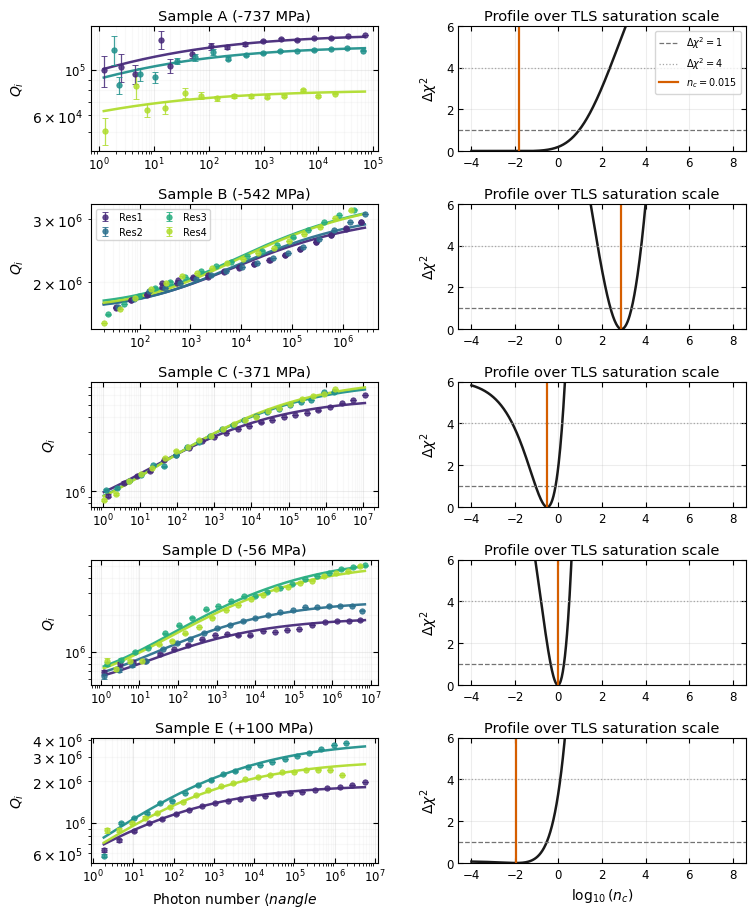

In [6]:
# ---------------------------------------------------------------------
# Nice plot: 5-panel sample-by-sample power fits + nc profile
# ---------------------------------------------------------------------


def plot_power_sweep_fits_paper(
    power_results,
    figsize=(7.4, 9.2),
    cmap_name="viridis",
    n_fit_points=1000,
    plot_loss=False,
    show_profiles=True,
    savepath=None,
):
    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    n_samples = len(samples)
    ncols = 2 if show_profiles else 1

    fig, axs = plt.subplots(
        n_samples,
        ncols,
        figsize=figsize,
        squeeze=False,
        constrained_layout=False,
    )

    cmap = mpl.colormaps[cmap_name]

    title_fs = 10.5
    label_fs = 10
    tick_fs = 8.5
    legend_fs = 7.0

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        ax = axs[i, 0]
        axp = axs[i, 1] if show_profiles else None

        res_groups = list(df_s.groupby("res_id"))
        colors = cmap(np.linspace(0.12, 0.88, len(res_groups)))

        nplot = np.logspace(
            np.log10(df_s["n"].min()),
            np.log10(df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")
            label = res_id.split("::")[-1]

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            y_invQ_fit = Cj + A * th * tls_saturation_shape(
                nplot,
                np.log10(tls["nc"]),
                beta=tls["beta"],
            )

            if plot_loss:
                y_data = df_r["invQ"]
                y_err = df_r["invQ_err"]
                y_fit = y_invQ_fit
                ylabel = r"$1/Q_i$"
            else:
                y_data = df_r["Qi"]
                y_err = df_r["Qi_err"]
                y_fit = 1.0 / y_invQ_fit
                ylabel = r"$Q_i$"

            ax.errorbar(
                df_r["n"],
                y_data,
                yerr=y_err,
                fmt="o",
                ms=3.8,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=0.9,
                markeredgewidth=0.7,
                alpha=0.85,
                label=label,
                zorder=5,
            )

            ax.plot(
                nplot,
                y_fit,
                "-",
                lw=1.8,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"{sample} ({stress:+.0f} MPa)", fontsize=title_fs, pad=4)
        ax.set_ylabel(ylabel, fontsize=label_fs)
        ax.grid(True, which="major", alpha=0.22)
        ax.grid(True, which="minor", alpha=0.08)
        ax.tick_params(axis="both", labelsize=tick_fs, direction="in", top=True, right=True)

        if i == n_samples - 1:
            ax.set_xlabel(r"Photon number $\langle nangle$", fontsize=label_fs)

        # Put legend on Sample B if present; otherwise first row.
        if sample == "Sample B" or ("Sample B" not in samples and i == 0):
            ax.legend(
                fontsize=legend_fs,
                ncol=2,
                frameon=True,
                handlelength=1.3,
                borderpad=0.35,
                loc="best",
            )

        if show_profiles:
            profile = tls["profile"]
            axp.plot(profile["log10_nc"], profile["delta_chi2"], color="0.1", lw=1.8)
            axp.axhline(1, color="0.45", ls="--", lw=0.9, label=r"$\Delta\chi^2=1$")
            axp.axhline(4, color="0.65", ls=":", lw=0.9, label=r"$\Delta\chi^2=4$")
            axp.axvline(np.log10(tls["nc"]), color="#D55E00", lw=1.6, label=rf"$n_c={tls['nc']:.2g}$")
            axp.set_ylim(0, 6)
            axp.set_ylabel(r"$\Delta\chi^2$", fontsize=label_fs)
            axp.set_title("Profile over TLS saturation scale", fontsize=title_fs, pad=4)
            axp.grid(alpha=0.22)
            axp.tick_params(axis="both", labelsize=tick_fs, direction="in", top=True, right=True)
            if i == n_samples - 1:
                axp.set_xlabel(r"$\log_{10}(n_c)$", fontsize=label_fs)
            if i == 0:
                axp.legend(fontsize=legend_fs, frameon=True, loc="best")

    fig.subplots_adjust(
        left=0.10,
        right=0.985,
        bottom=0.07,
        top=0.98,
        wspace=0.28,
        hspace=0.42,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig


fig = plot_power_sweep_fits_paper(
    power_results,
    figsize=(7.4, 9.2),
    cmap_name="viridis",
    plot_loss=False,
    show_profiles=True,
    savepath="power_tls_saturation_fits.png",
)
plt.show()


In [7]:
# ---------------------------------------------------------------------
# Compare power-fit high-power floors to temperature-fit non-TLS floors
# ---------------------------------------------------------------------
def build_floor_comparison_df(power_results, fixed_results, T_base_mK=100.0):
    if fixed_results is None:
        raise ValueError("fixed_results is None. Load fixed_results.pkl first to make this comparison.")

    loss_fit = fixed_results["loss_profile"]["best_fit"]
    params = loss_fit["params"]
    Tc2 = loss_fit["Tc2"]
    Gamma = loss_fit["Gamma"]

    rows = []
    for sample, result in power_results.items():
        df_s = result["data"]
        tls = result["tls_saturation"]
        A_sec = _param_value(params, "A_secondary", sample, default=np.nan)

        for res_id, C_power in tls["C_res"].items():
            df_r = df_s[df_s["res_id"] == res_id]
            if len(df_r) == 0:
                continue

            f_res = float(df_r["f_res"].median())
            stress = float(df_r["stress"].iloc[0])
            stress_err = float(df_r["stress_err"].iloc[0]) if "stress_err" in df_r else np.nan

            C_temp = _param_value(params, "C_res", res_id, default=np.nan)
            g_sec = mb_loss_shape(T_base_mK, Tc2, Gamma, f_res)
            g_nb = mb_loss_shape(T_base_mK, TC_NB, GAMMA_NB, f_res)
            floor_temp = C_temp + A_sec * g_sec + g_nb

            rows.append({
                "sample": sample,
                "label": res_id.split("::")[-1],
                "res_id": res_id,
                "stress": stress,
                "stress_err": stress_err,
                "f_res": f_res,
                "C_power": C_power,
                "C_temp": C_temp,
                "A_sec_temp": A_sec,
                "g_sec_100mK": g_sec,
                "g_nb_100mK": g_nb,
                "floor_temp_model": floor_temp,
                "ratio_power_to_temp_floor": C_power / floor_temp if np.isfinite(floor_temp) and floor_temp > 0 else np.nan,
                "delta_power_minus_temp_floor": C_power - floor_temp,
            })

    out = pd.DataFrame(rows)
    out = out[np.isfinite(out["C_power"]) & np.isfinite(out["floor_temp_model"]) & (out["floor_temp_model"] > 0)].copy()
    return out.sort_values(["stress", "sample", "label"])


def plot_floor_comparison(floor_df, figsize=(3.6, 3.3), cmap_name="plasma", savepath=None):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    stress_vals = floor_df["stress"].to_numpy(float)
    norm = mpl.colors.Normalize(vmin=np.nanmin(stress_vals), vmax=np.nanmax(stress_vals))
    cmap = mpl.colormaps[cmap_name]

    for _, row in floor_df.iterrows():
        ax.errorbar(
            row["floor_temp_model"],
            row["C_power"],
            fmt="o",
            ms=5.5,
            color=cmap(norm(row["stress"])),
            alpha=0.9,
        )

    x = floor_df["floor_temp_model"].to_numpy(float)
    y = floor_df["C_power"].to_numpy(float)
    lo = min(np.nanmin(x), np.nanmin(y)) * 0.7
    hi = max(np.nanmax(x), np.nanmax(y)) * 1.4
    ax.plot([lo, hi], [lo, hi], "--", color="0.35", lw=1.0, label="1:1")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(r"Temperature-fit non-TLS floor")
    ax.set_ylabel(r"Power-fit high-power floor $C_j^P$")
    ax.grid(True, which="major", alpha=0.22)
    ax.grid(True, which="minor", alpha=0.10)
    ax.tick_params(direction="in", top=True, right=True, labelsize=9)
    ax.legend(fontsize=8, frameon=True, loc="best")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Stress [MPa]")
    cbar.ax.tick_params(labelsize=8)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig


if fixed_results is not None:
    floor_comparison_df = build_floor_comparison_df(power_results, fixed_results, T_base_mK=100.0)
    display(floor_comparison_df)

    fig = plot_floor_comparison(
        floor_comparison_df,
        figsize=(3.6, 3.3),
        cmap_name="plasma",
        savepath="power_floor_vs_temperature_floor.png",
    )
    plt.show()
else:
    print("Skipping floor comparison: fixed_results is not loaded.")


Skipping floor comparison: fixed_results is not loaded.


In [8]:
# ---------------------------------------------------------------------
# Useful summary table for appendix text
# ---------------------------------------------------------------------
summary_cols = [
    "sample", "stress", "npts", "n_res", "n_min", "n_max",
    "nc_best", "nc_1sigma_low", "nc_1sigma_high",
    "A_TLS", "chi2_red_tls", "nc_at_boundary",
]
display(power_summary[summary_cols])


,sample,stress,npts,n_res,n_min,n_max,nc_best,nc_1sigma_low,nc_1sigma_high,A_TLS,chi2_red_tls,nc_at_boundary
0,Sample A,-737.4,46,3,1.21,70900.0,0.015276,0.000100,8.790225,1.172449e-05,0.358852,False
1,Sample B,-542.3,85,4,19.70,2720000.0,772.680585,255.858589,2208.004733,3.641224e-07,0.124724,False
2,Sample C,-371.3,64,3,1.08,11300000.0,0.301995,0.089536,0.731139,1.832466e-06,0.218876,False
3,Sample D,-56.3,84,4,1.20,6950000.0,0.963829,0.444631,1.770109,1.933138e-06,0.348610,False
4,Sample E,100.3,61,3,1.84,5630000.0,0.010965,0.000100,0.285759,4.329663e-06,0.329446,False


In [9]:
# ---------------------------------------------------------------------
# Paper-style 5-column power-sweep fits only
# ---------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
})

def plot_power_sweep_fits_5col(
    power_results,
    figsize=(16, 4),
    cmap_name="viridis",
    n_fit_points=1000,
    plot_loss=False,
    savepath=None,
):
    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    n_samples = len(samples)

    fig, axs = plt.subplots(
        1,
        n_samples,
        figsize=figsize,
        sharey=True,
        squeeze=False,
        constrained_layout=False,
    )

    axs = axs[0]

    cmap = mpl.colormaps[cmap_name]

    freqs = []
    for sample in samples:
        for freq in power_results[sample]['data']['f_res'].unique():
            freqs.append(freq)
    f_min = np.min(freqs)
    f_max = np.max(freqs)
    print(f_min, f_max)
    

    title_fs = 13
    label_fs = 16
    tick_fs = 10
    legend_fs = 9

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        ax = axs[i]

        res_groups = list(df_s.groupby("res_id"))
        # colors = cmap(np.linspace(0.12, 0.88, len(res_groups)))

        freqs = df_s['f_res'].unique()
        colors = cmap(0.12 + 0.76 * (freqs - f_min) / (f_max - f_min))

        margine = 2
        nplot = np.logspace(
            np.log10(df_s["n"].min()/margine),
            np.log10(margine*df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")
            label = res_id.split("::")[-1]

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            y_invQ_fit = Cj + A * th * tls_saturation_shape(
                nplot,
                np.log10(tls["nc"]),
                beta=tls["beta"],
            )

            if plot_loss:
                y_data = df_r["invQ"]
                y_err = df_r["invQ_err"]
                y_fit = y_invQ_fit
                ylabel = r"$1/Q_i$"
            else:
                y_data = df_r["Qi"]
                y_err = df_r["Qi_err"]
                y_fit = 1.0 / y_invQ_fit
                ylabel = r"$Q_i$"

            ax.errorbar(
                df_r["n"],
                y_data,
                yerr=y_err,
                fmt="o",
                ms=3.5,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=0.9,
                markeredgewidth=0.7,
                alpha=0.85,
                label=label,
                zorder=5,
            )

            ax.plot(
                nplot,
                y_fit,
                "-",
                lw=2.0,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]
        stress_err = df_s["stress_err"].iloc[0]

        stress_label = f'{stress:.0f}$\\pm${stress_err:.0f}$\\,$MPa'.replace('-', '$-$')
        ax.set_title(stress_label, fontsize=title_fs, pad=6)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="major", alpha=0.22)
        ax.grid(True, which="minor", alpha=0.08)

        ax.tick_params(
            axis="both",
            labelsize=tick_fs,
            direction="in",
            top=True,
            right=True,
        )

        ax.set_xlabel(
            r"Photon number $\langle n\rangle$",
            fontsize=label_fs,
        )

        if i == 0:
            ax.set_ylabel(ylabel, fontsize=label_fs)
        Qi_all = []

        for sample in power_results.values():
            Qi_all.extend(sample["data"]["Qi"])
        
        Qi_all = np.asarray(Qi_all)
        if plot_loss:
            ymin = 0.8*np.nanmin(1/Qi_all)
            ymax = 1.2*np.nanmax(1/Qi_all)
        else:
            ymin = 0.8*np.nanmin(Qi_all)
            ymax = 1.2*np.nanmax(Qi_all)

        ax.set_xlim(df_s["n"].min()/margine, margine*df_s["n"].max())
        ax.set_ylim(ymin, ymax)


    fig.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.11,
        top=0.82,
        wspace=0.28,
        hspace=0.25,
    )

    fig.tight_layout(pad=0.4, w_pad=.75, h_pad=1.0)

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

4231876180.0 6265521980.0


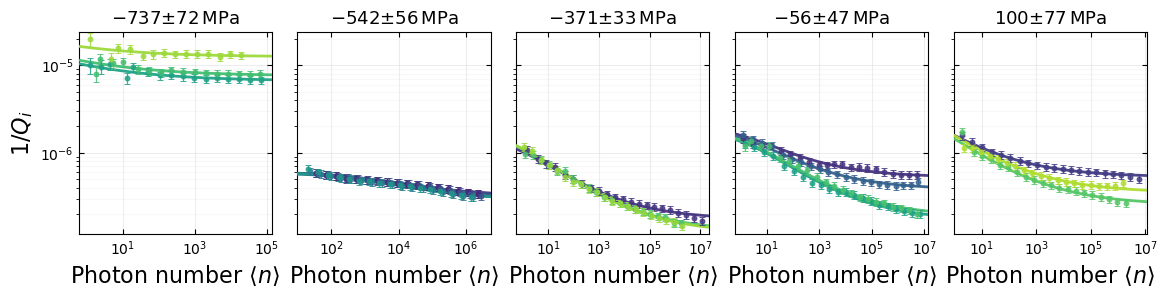

In [10]:
fig = plot_power_sweep_fits_5col(
    power_results,
    figsize=(15.5*.75, 3.9*.75),
    cmap_name="viridis",
    plot_loss=True,
    savepath="tls_saturation.pdf",
)

plt.show()

In [11]:
power_results['Sample A']['data']['f_res'].unique()

array([5.45667568e+09, 5.77765468e+09, 6.19093884e+09])

In [12]:
list(power_results['Sample A']['data'].groupby("res_id"))

[('Sample A::Res2',
        sample label          res_id  stress  stress_err         n         Qi  \
  0   Sample A  Res2  Sample A::Res2  -737.4        71.7      1.21  100031.31   
  1   Sample A  Res2  Sample A::Res2  -737.4        71.7      2.47  103682.77   
  2   Sample A  Res2  Sample A::Res2  -737.4        71.7      4.53   96314.35   
  3   Sample A  Res2  Sample A::Res2  -737.4        71.7     13.40  140906.04   
  4   Sample A  Res2  Sample A::Res2  -737.4        71.7     19.70  105207.29   
  5   Sample A  Res2  Sample A::Res2  -737.4        71.7     49.60  119787.54   
  6   Sample A  Res2  Sample A::Res2  -737.4        71.7    109.00  130701.76   
  7   Sample A  Res2  Sample A::Res2  -737.4        71.7    217.00  129767.52   
  8   Sample A  Res2  Sample A::Res2  -737.4        71.7    462.00  134560.93   
  9   Sample A  Res2  Sample A::Res2  -737.4        71.7    980.00  138917.60   
  10  Sample A  Res2  Sample A::Res2  -737.4        71.7   2050.00  141979.39   
  11  Sa

In [13]:
# ---------------------------------------------------------------------
# Paper-style power sweep figure:
#   top row: Q_i vs photon number
#   bottom row: normalized TLS saturation fraction
# ---------------------------------------------------------------------

def plot_power_sweep_fits_with_tls_fraction(
    power_results,
    figsize=(15.5, 6.4),
    cmap_name="viridis",
    n_fit_points=1000,
    savepath=None,
    ylims_Qi=(5e4, 6e6),
    ylims_frac=(3e-3, 2.0),
    xlims=(0.5, 2e7),
    n_temp_range=None,   # e.g. (1e5, 1e6)
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    fig, axs = plt.subplots(
        2,
        len(samples),
        figsize=figsize,
        sharex=False,
        sharey="row",
        squeeze=False,
        constrained_layout=False,
    )

    cmap = mpl.colormaps[cmap_name]

    title_fs = 15
    label_fs = 15
    tick_fs = 12
    legend_fs = 9
    ms = 4.2
    lw = 2.2

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        axQ = axs[0, i]
        axF = axs[1, i]

        res_groups = list(df_s.groupby("res_id"))
        colors = cmap(np.linspace(0.12, 0.88, len(res_groups)))

        nplot = np.logspace(
            np.log10(df_s["n"].min()),
            np.log10(df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")
            label = res_id.split("::")[-1]

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            sat_fit = tls_saturation_shape(
                nplot,
                np.log10(tls["nc"]),
                beta=tls["beta"],
            )

            y_invQ_fit = Cj + A * th * sat_fit
            y_Q_fit = 1.0 / y_invQ_fit

            # Raw Qi data
            Qi_data = df_r["Qi"].to_numpy(float)
            Qi_err = df_r["Qi_err"].to_numpy(float)

            good_Q = (
                np.isfinite(df_r["n"])
                & np.isfinite(Qi_data)
                & np.isfinite(Qi_err)
                & (df_r["n"] > 0)
                & (Qi_data > 0)
                & (Qi_err > 0)
            )

            axQ.errorbar(
                df_r.loc[good_Q, "n"],
                Qi_data[good_Q],
                yerr=Qi_err[good_Q],
                fmt="o",
                ms=ms,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=1.0,
                markeredgewidth=0.7,
                alpha=0.88,
                label=label,
                zorder=5,
            )

            axQ.plot(
                nplot,
                y_Q_fit,
                "-",
                lw=lw,
                color=color,
                alpha=0.95,
                zorder=4,
            )

            # Normalized TLS fraction:
            #   F_TLS = (delta - Cj)/(A_TLS * tanh)
            invQ_data = df_r["invQ"].to_numpy(float)
            invQ_err = df_r["invQ_err"].to_numpy(float)

            denom = A * th
            frac_data = (invQ_data - Cj) / denom
            frac_err = invQ_err / denom

            good_F = (
                np.isfinite(df_r["n"])
                & np.isfinite(frac_data)
                & np.isfinite(frac_err)
                & (df_r["n"] > 0)
                & (frac_data > 0)
                & (frac_err > 0)
            )

            axF.errorbar(
                df_r.loc[good_F, "n"],
                frac_data[good_F],
                yerr=frac_err[good_F],
                fmt="o",
                ms=ms,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=1.0,
                markeredgewidth=0.7,
                alpha=0.88,
                zorder=5,
            )

            axF.plot(
                nplot,
                sat_fit,
                "-",
                lw=lw,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]

        axQ.set_title(
            f"{sample}\n{stress:+.0f} MPa",
            fontsize=title_fs,
            pad=6,
        )

        for ax in (axQ, axF):
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(xlims)

            if n_temp_range is not None:
                ax.axvspan(
                    n_temp_range[0],
                    n_temp_range[1],
                    color="0.8",
                    alpha=0.25,
                    zorder=0,
                )

            ax.grid(True, which="major", alpha=0.22)
            ax.grid(True, which="minor", alpha=0.08)
            ax.tick_params(
                axis="both",
                labelsize=tick_fs,
                direction="in",
                top=True,
                right=True,
            )

        axQ.set_ylim(ylims_Qi)
        axF.set_ylim(ylims_frac)

        if i == 0:
            axQ.set_ylabel(r"$Q_i$", fontsize=label_fs)
            axF.set_ylabel(
                r"TLS fraction $(\delta-C_j)/(A_{\rm TLS}\tanh)$",
                fontsize=label_fs,
            )

        axF.set_xlabel(
            r"Photon number $\langle n\rangle$",
            fontsize=label_fs,
        )

        if sample == "Sample B" or ("Sample B" not in samples and i == 0):
            axQ.legend(
                fontsize=legend_fs,
                ncol=1,
                frameon=True,
                handlelength=1.3,
                borderpad=0.35,
                loc="best",
            )

    fig.subplots_adjust(
        left=0.065,
        right=0.995,
        bottom=0.12,
        top=0.88,
        wspace=0.18,
        hspace=0.18,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

In [14]:
# ---------------------------------------------------------------------
# Collapsed TLS saturation plot
# ---------------------------------------------------------------------

def plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2, 4.0),
    cmap_name="plasma",
    n_fit_points=1000,
    beta_ref=None,
    n_temp_range=None,  # e.g. (1e5, 1e6), shown as range in n/nc approximately if using median nc
    savepath=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    stresses = np.array([
        _result_stress(power_results[s])
        for s in samples
    ])

    norm = mpl.colors.Normalize(
        vmin=np.nanmin(stresses),
        vmax=np.nanmax(stresses),
    )
    cmap = mpl.colormaps[cmap_name]

    fig, ax = plt.subplots(figsize=figsize)

    all_beta = []
    all_nc = []

    for sample in samples:
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        stress = _result_stress(result)
        color = cmap(norm(stress))

        A = tls["A_TLS"]
        nc = tls["nc"]
        beta = tls["beta"]

        all_beta.append(beta)
        all_nc.append(nc)

        for res_id, df_r in df_s.groupby("res_id"):
            df_r = df_r.sort_values("n")

            Cj = tls["C_res"][res_id]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            x = df_r["n"].to_numpy(float) / nc
            y = (df_r["invQ"].to_numpy(float) - Cj) / (A * th)
            yerr = df_r["invQ_err"].to_numpy(float) / (A * th)

            good = (
                np.isfinite(x)
                & np.isfinite(y)
                & np.isfinite(yerr)
                & (x > 0)
                & (y > 0)
                & (yerr > 0)
            )

            ax.errorbar(
                x[good],
                y[good],
                yerr=yerr[good],
                fmt="o",
                ms=3.5,
                capsize=1.6,
                color=color,
                ecolor=color,
                alpha=0.55,
                elinewidth=0.8,
                markeredgewidth=0.6,
                zorder=4,
            )

    if beta_ref is None:
        beta_ref = float(np.nanmedian(all_beta))

    xplot = np.logspace(-5, 7, n_fit_points)
    yplot = 1.0 / np.sqrt(1.0 + xplot**beta_ref)

    ax.plot(
        xplot,
        yplot,
        color="black",
        lw=2.4,
        zorder=6,
        label=rf"$[1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, $\beta={beta_ref:.2g}$",
    )

    # ax.axvline(
    #     1.0,
    #     color="0.35",
    #     ls="--",
    #     lw=1.0,
    #     zorder=2,
    # )

    # ax.text(
    #     1.1,
    #     1.2,
    #     r"$\langle n\rangle=n_c$",
    #     fontsize=10,
    #     rotation=90,
    #     va="top",
    #     ha="left",
    # )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Scaled photon number $\langle n\rangle/n_c$",
        fontsize=12,
    )
    ax.set_ylabel(
        r"$[1/Q_i-\delta_0]/\delta_\mathrm{TLS}$",
        fontsize=12,
    )

    ax.set_xlim(1e-5, 1e7)
    ax.set_ylim(2e-3, 3)

    ax.grid(True, which="major", alpha=0.24)
    ax.grid(True, which="minor", alpha=0.08)

    ax.tick_params(
        axis="both",
        labelsize=10,
        direction="in",
        top=True,
        right=True,
    )

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="lower left", framealpha=1,
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Stress [MPa]", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

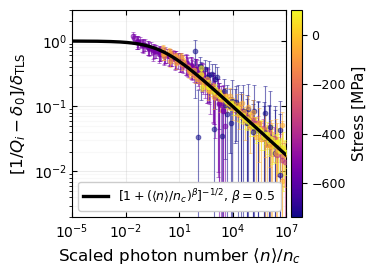

In [15]:
fig = plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2*.75, 4.0*.75),
    cmap_name="plasma",
    savepath="tls_saturation_collapse.png",
)

plt.show()

In [16]:
# ---------------------------------------------------------------------
# Collapsed TLS saturation plot with approximate temperature-sweep band
# ---------------------------------------------------------------------

def plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2, 4.0),
    cmap_name="plasma",
    n_fit_points=1000,
    beta_ref=None,
    temp_photon_ranges=None,
    temp_band_percentiles=(5, 95),
    savepath=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    stresses = np.array([
        _result_stress(power_results[s])
        for s in samples
    ])

    norm = mpl.colors.Normalize(
        vmin=np.nanmin(stresses),
        vmax=np.nanmax(stresses),
    )
    cmap = mpl.colormaps[cmap_name]

    fig, ax = plt.subplots(figsize=figsize)

    all_beta = []
    all_nc = []

    # ------------------------------------------------------------
    # Approximate photon-number ranges during temperature sweeps
    # estimated from JT's Fig. S4.
    #
    # These are intentionally rough. Replace with actual values
    # once the temperature-sweep photon-number dataframe is available.
    # ------------------------------------------------------------
    if temp_photon_ranges is None:
        temp_photon_ranges = {
            "Sample A": (7, 1.5e3),
            "Sample B": (6e1, 5e4),
            "Sample C": (1e2, 2.2e5),
            "Sample D": (6e1, 1.4e5),
            "Sample E": (1e4, 8e4),
        }

    x_temp_vals = []

    # ------------------------------------------------------------
    # Plot normalized TLS-collapse data
    # ------------------------------------------------------------
    for sample in samples:
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        stress = _result_stress(result)
        color = cmap(norm(stress))

        A = tls["A_TLS"]
        nc = tls["nc"]
        beta = tls["beta"]

        all_beta.append(beta)
        all_nc.append(nc)

        # Convert approximate temperature-sweep photon-number range
        # into collapsed coordinate n/nc.
        if sample in temp_photon_ranges:
            nlo, nhi = temp_photon_ranges[sample]
            x_temp_vals.extend([nlo / nc, nhi / nc])

        for res_id, df_r in df_s.groupby("res_id"):
            df_r = df_r.sort_values("n")

            Cj = tls["C_res"][res_id]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            x = df_r["n"].to_numpy(float) / nc
            y = (df_r["invQ"].to_numpy(float) - Cj) / (A * th)
            yerr = df_r["invQ_err"].to_numpy(float) / (A * th)

            good = (
                np.isfinite(x)
                & np.isfinite(y)
                & np.isfinite(yerr)
                & (x > 0)
                & (y > 0)
                & (yerr > 0)
            )

            ax.errorbar(
                x[good],
                y[good],
                yerr=yerr[good],
                fmt="o",
                ms=3.5,
                capsize=1.6,
                color=color,
                ecolor=color,
                alpha=0.55,
                elinewidth=0.8,
                markeredgewidth=0.6,
                zorder=4,
            )

    # ------------------------------------------------------------
    # Shaded temperature-sweep region in n/nc
    # ------------------------------------------------------------
    x_temp_vals = np.asarray(x_temp_vals, dtype=float)
    x_temp_vals = x_temp_vals[np.isfinite(x_temp_vals) & (x_temp_vals > 0)]

    if len(x_temp_vals):
        xlo, xhi = np.nanpercentile(x_temp_vals, temp_band_percentiles)
        xmed = np.nanmedian(x_temp_vals)

        ax.axvspan(
            xlo,
            xhi,
            color="0.85",
            alpha=0.45,
            zorder=0,
        )

        # ax.text(
        #     xmed,
        #     0.025,
        #     "temperature\nsweeps",
        #     ha="center",
        #     va="bottom",
        #     fontsize=8,
        #     color="0.25",
        #     zorder=20,
        # )

    # ------------------------------------------------------------
    # Universal TLS saturation model
    # ------------------------------------------------------------
    if beta_ref is None:
        beta_ref = float(np.nanmedian(all_beta))

    xplot = np.logspace(-5, 7, n_fit_points)
    yplot = 1.0 / np.sqrt(1.0 + xplot**beta_ref)

    ax.plot(
        xplot,
        yplot,
        color="black",
        lw=2.4,
        zorder=6,
        label=rf"$[1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, $\beta={beta_ref:.2g}$",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Scaled photon number $\langle n\rangle/n_c$",
        fontsize=12,
    )
    ax.set_ylabel(
        r"$[1/Q_i-\delta_0]/\delta_\mathrm{TLS}$",
        fontsize=12,
    )

    ax.set_xlim(1e-5, 1e7)
    ax.set_ylim(2e-3, 3)

    ax.grid(True, which="major", alpha=0.24)
    ax.grid(True, which="minor", alpha=0.08)

    ax.tick_params(
        axis="both",
        labelsize=10,
        direction="in",
        top=True,
        right=True,
    )

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="lower left",
        framealpha=1,
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Stress [MPa]", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

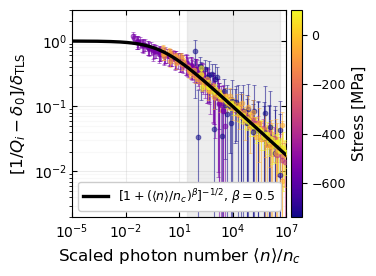

In [17]:
fig = plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2*.75, 4.0*.75),
    cmap_name="plasma",
    temp_band_percentiles=(5, 95),
    savepath="tls_saturation_collapse.pdf",
)

plt.show()

In [18]:
# =====================================================================
# Photon number and TLS saturation stability from T_ref to 1 K
#
# Requires:
#   stress_resonators
#   power_results
#   _result_stress(...)
#
# Produces:
#   photon_stability_resonator
#   photon_stability_sample
#   temp_scaled_ranges
# =====================================================================

import numpy as np
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------------------
# Experimental constants used for the temperature sweeps
# ---------------------------------------------------------------------

P_SOURCE_DBM = -10.0
ATTENUATION_DB = 96.0
P_DEVICE_DBM = P_SOURCE_DBM - ATTENUATION_DB

GAMMA_MISMATCH = 0.0
HALFWAVE = 0              # 0 = quarter-wave, 1 = half-wave

T_TARGET_MK = 900.0
T_TOLERANCE_MK = 75.0

H_PLANCK = 6.62607015e-34


def photon_number(
    pwr_dBm,
    f0_Hz,
    Q_loaded,
    Qc,
    gamma=GAMMA_MISMATCH,
    halfwave=HALFWAVE,
):
    """
    Intra-resonator photon number using the convention employed
    in the postdoc's calculation.
    """
    pwr_W = 10.0**((float(pwr_dBm) - 30.0) / 10.0)

    f0_Hz = np.asarray(f0_Hz, dtype=float)
    Q_loaded = np.asarray(Q_loaded, dtype=float)
    Qc = np.asarray(Qc, dtype=float)

    factor_P = 2 - halfwave
    factor_N = 4 - 2 * halfwave

    P_int = (
        (1.0 - gamma**2)
        * factor_P
        * Q_loaded**2
        / (np.pi * Qc)
        * pwr_W
    )

    return P_int / (factor_N * H_PLANCK * f0_Hz**2)


def tls_saturation_factor(n, nc, beta):
    """S(n) = [1 + (n/nc)^beta]^(-1/2)."""
    n = np.asarray(n, dtype=float)

    return 1.0 / np.sqrt(
        1.0 + (n / float(nc))**float(beta)
    )


def _nearest_index(values, target):
    values = np.asarray(values, dtype=float)
    return int(np.nanargmin(np.abs(values - target)))


rows = []
skipped = []

for sample, chip in stress_resonators.items():

    if sample == "All Film":
        continue

    if not isinstance(chip, dict):
        continue

    if sample not in power_results:
        skipped.append((sample, None, "sample absent from power_results"))
        continue

    tls_fit = power_results[sample]["tls_saturation"]
    nc = float(tls_fit["nc"])
    beta = float(tls_fit["beta"])

    stress = chip.get(
        "stress",
        _result_stress(power_results[sample]),
    )
    stress_err = chip.get("stress_err", np.nan)

    for res_name, rd in chip.items():

        if not isinstance(rd, dict):
            continue

        needed = {"Temp", "Qi_Temp", "Qc_Temp", "Freq"}

        if not needed.issubset(rd):
            continue

        T = np.asarray(rd["Temp"], dtype=float)
        Qi = np.asarray(rd["Qi_Temp"], dtype=float)
        Qc = np.asarray(rd["Qc_Temp"], dtype=float)
        freq = np.asarray(rd["Freq"], dtype=float)

        # If frequency is stored as a scalar, broadcast it.
        if freq.ndim == 0 or freq.size == 1:
            freq = np.full_like(T, float(freq.ravel()[0]))

        npts = min(len(T), len(Qi), len(Qc), len(freq))

        T = T[:npts]
        Qi = Qi[:npts]
        Qc = Qc[:npts]
        freq = freq[:npts]

        good = (
            np.isfinite(T)
            & np.isfinite(Qi)
            & np.isfinite(Qc)
            & np.isfinite(freq)
            & (Qi > 0)
            & (Qc > 0)
            & (freq > 0)
            & (T <= T_TARGET_MK + T_TOLERANCE_MK)
        )

        if np.count_nonzero(good) < 2:
            skipped.append((sample, res_name, "fewer than two valid points"))
            continue

        T = T[good]
        Qi = Qi[good]
        Qc = Qc[good]
        freq = freq[good]

        order = np.argsort(T)

        T = T[order]
        Qi = Qi[order]
        Qc = Qc[order]
        freq = freq[order]

        # Loaded quality factor
        Q_loaded = 1.0 / (1.0 / Qi + 1.0 / Qc)

        # Absolute photon number at every temperature point
        n_photon = photon_number(
            P_DEVICE_DBM,
            freq,
            Q_loaded,
            Qc,
        )

        # TLS saturation factor at every temperature point
        S = tls_saturation_factor(
            n_photon,
            nc,
            beta,
        )

        # Base-temperature reference
        i_ref = 0

        T_ref = float(T[i_ref])
        n_ref = float(n_photon[i_ref])
        S_ref = float(S[i_ref])

        # Nearest available point to 1 K
        i_1K = _nearest_index(T, T_TARGET_MK)

        if abs(T[i_1K] - T_TARGET_MK) > T_TOLERANCE_MK:
            skipped.append(
                (
                    sample,
                    res_name,
                    f"nearest point is {T[i_1K]:.1f} mK",
                )
            )
            continue

        T_1K = float(T[i_1K])
        n_1K = float(n_photon[i_1K])
        S_1K = float(S[i_1K])

        # Restrict ranges explicitly to T_ref through the selected 1 K point
        within = T <= T_1K

        n_fit_range = n_photon[within]
        S_fit_range = S[within]
        x_fit_range = n_fit_range / nc

        rows.append({
            "sample": sample,
            "resonator": res_name,
            "stress_MPa": float(stress),
            "stress_err_MPa": float(stress_err)
                if np.isfinite(stress_err) else np.nan,

            "f_ref_GHz": float(freq[i_ref] / 1e9),

            "nc": nc,
            "beta": beta,

            "T_ref_mK": T_ref,
            "T_1K_mK": T_1K,

            "n_ref": n_ref,
            "n_1K": n_1K,
            "n_ratio_1K_ref": n_1K / n_ref,
            "n_percent_change": 100.0 * (n_1K / n_ref - 1.0),

            "S_ref": S_ref,
            "S_1K": S_1K,
            "S_ratio_1K_ref": S_1K / S_ref,
            "S_percent_change": 100.0 * (S_1K / S_ref - 1.0),

            # Ranges used for the colored bands
            "n_min_Tref_to_1K": float(np.nanmin(n_fit_range)),
            "n_max_Tref_to_1K": float(np.nanmax(n_fit_range)),
            "x_min_Tref_to_1K": float(np.nanmin(x_fit_range)),
            "x_max_Tref_to_1K": float(np.nanmax(x_fit_range)),
            "S_min_Tref_to_1K": float(np.nanmin(S_fit_range)),
            "S_max_Tref_to_1K": float(np.nanmax(S_fit_range)),
        })


if not rows:
    raise RuntimeError(
        "No valid temperature-sweep resonators were found. "
        "Check the required keys and temperature units."
    )


photon_stability_resonator = (
    pd.DataFrame(rows)
    .sort_values(
        ["stress_MPa", "f_ref_GHz", "resonator"]
    )
    .reset_index(drop=True)
)

print("Per-resonator photon-number and saturation stability:")
display(
    photon_stability_resonator[
        [
            "sample",
            "resonator",
            "stress_MPa",
            "f_ref_GHz",
            "T_ref_mK",
            "T_1K_mK",
            "n_ref",
            "n_1K",
            "n_percent_change",
            "S_ref",
            "S_1K",
            "S_percent_change",
            "x_min_Tref_to_1K",
            "x_max_Tref_to_1K",
        ]
    ]
)


photon_stability_sample = (
    photon_stability_resonator
    .groupby("sample", as_index=False)
    .agg(
        stress_MPa=("stress_MPa", "first"),
        n_resonators=("resonator", "nunique"),

        median_n_ref=("n_ref", "median"),
        median_n_1K=("n_1K", "median"),

        median_n_percent_change=(
            "n_percent_change",
            "median",
        ),
        min_n_percent_change=(
            "n_percent_change",
            "min",
        ),
        max_n_percent_change=(
            "n_percent_change",
            "max",
        ),
        max_abs_n_percent_change=(
            "n_percent_change",
            lambda x: np.nanmax(np.abs(x)),
        ),

        median_S_ref=("S_ref", "median"),
        median_S_1K=("S_1K", "median"),

        median_S_percent_change=(
            "S_percent_change",
            "median",
        ),
        min_S_percent_change=(
            "S_percent_change",
            "min",
        ),
        max_S_percent_change=(
            "S_percent_change",
            "max",
        ),
        max_abs_S_percent_change=(
            "S_percent_change",
            lambda x: np.nanmax(np.abs(x)),
        ),

        x_min=("x_min_Tref_to_1K", "min"),
        x_max=("x_max_Tref_to_1K", "max"),
        S_min=("S_min_Tref_to_1K", "min"),
        S_max=("S_max_Tref_to_1K", "max"),
    )
    .sort_values("stress_MPa")
    .reset_index(drop=True)
)

print("\nPer-sample summary:")
display(photon_stability_sample)


# Dictionary consumed by the collapse-plot cell
temp_scaled_ranges = {
    row["sample"]: (
        float(row["x_min"]),
        float(row["x_max"]),
    )
    for _, row in photon_stability_sample.iterrows()
}


print("\nScaled photon-number ranges, T_ref to 1 K:")
for sample, (xlo, xhi) in temp_scaled_ranges.items():
    print(f"{sample:8s}: {xlo:.3g} to {xhi:.3g}")


print("\nOverall stability:")
print(
    "Median photon-number change: "
    f"{photon_stability_resonator['n_percent_change'].median():+.2f}%"
)
print(
    "Largest absolute photon-number change: "
    f"{photon_stability_resonator['n_percent_change'].abs().max():.2f}%"
)
print(
    "Median TLS saturation-factor change: "
    f"{photon_stability_resonator['S_percent_change'].median():+.2f}%"
)
print(
    "Largest absolute TLS saturation-factor change: "
    f"{photon_stability_resonator['S_percent_change'].abs().max():.2f}%"
)

if skipped:
    print(f"\nSkipped {len(skipped)} entries.")
    display(
        pd.DataFrame(
            skipped,
            columns=["sample", "resonator", "reason"],
        ).head(20)
    )

Per-resonator photon-number and saturation stability:


,sample,resonator,stress_MPa,f_ref_GHz,T_ref_mK,T_1K_mK,n_ref,n_1K,n_percent_change,S_ref,S_1K,S_percent_change,x_min_Tref_to_1K,x_max_Tref_to_1K
0,Sample A,Res2,-737.4,5.456844,100.19,907.47,1508.809444,789.140845,-47.697779,0.056319,0.066185,17.518576,5.166001e+04,9.877212e+04
1,Sample A,Res3,-737.4,5.777819,100.12,903.65,1778.703524,870.229211,-51.075084,0.054055,0.064593,19.493704,5.696835e+04,1.164404e+05
2,Sample A,Res4,-737.4,6.191113,100.16,903.20,492.661120,357.216333,-27.492486,0.074414,0.080603,8.316511,2.338467e+04,3.225138e+04
3,Sample B,Res1,-542.3,4.232138,149.89,904.61,56889.569202,48333.529903,-15.039733,0.323076,0.335030,3.700318,6.255305e+01,7.566566e+01
4,Sample B,Res2,-542.3,4.584632,149.86,906.04,64592.144500,48191.623241,-25.390891,0.313990,0.335249,6.770539,6.236940e+01,8.699112e+01
5,Sample B,Res3,-542.3,4.980364,149.39,906.97,40223.436713,29422.321584,-26.852790,0.348895,0.373437,7.034232,3.807825e+01,5.324517e+01
6,Sample B,Res4,-542.3,5.328891,149.71,904.58,33220.044184,21920.479511,-34.014298,0.363771,0.397581,9.294389,2.836939e+01,4.441991e+01
7,Sample C,Res1,-371.3,4.321975,102.51,909.81,241354.237906,291420.519500,20.743900,0.033427,0.031890,-4.598429,7.991990e+05,9.673387e+05
8,Sample C,Res2,-371.3,5.831139,100.47,908.85,42075.417652,44386.915707,5.493702,0.051691,0.051006,-1.324650,1.393248e+05,1.472136e+05
9,Sample C,Res3,-371.3,6.172683,99.69,898.06,44153.779853,45295.175670,2.585047,0.051073,0.050749,-0.634375,1.428765e+05,1.531136e+05



Per-sample summary:


,sample,stress_MPa,n_resonators,median_n_ref,median_n_1K,median_n_percent_change,min_n_percent_change,max_n_percent_change,max_abs_n_percent_change,median_S_ref,median_S_1K,median_S_percent_change,min_S_percent_change,max_S_percent_change,max_abs_S_percent_change,x_min,x_max,S_min,S_max
0,Sample A,-737.4,3,1508.809444,789.140845,-47.697779,-51.075084,-27.492486,51.075084,0.056319,0.066185,17.518576,8.316511,19.493704,19.493704,2.338467e+04,1.164404e+05,0.054055,0.080603
1,Sample B,-542.3,4,48556.502958,38806.972412,-26.121841,-34.014298,-15.039733,34.014298,0.335985,0.354343,6.902386,3.700318,9.294389,9.294389,2.836939e+01,8.699112e+01,0.311182,0.397581
2,Sample C,-371.3,3,44153.779853,45295.175670,5.493702,2.585047,20.743900,20.743900,0.051073,0.050749,-1.324650,-4.598429,-0.634375,4.598429,1.393248e+05,9.673387e+05,0.031870,0.051691
3,Sample D,-56.3,4,131071.820517,140295.263341,10.977289,5.206437,18.032899,18.032899,0.052158,0.051243,-2.542710,-4.050427,-1.257705,4.050427,1.115072e+05,1.859786e+05,0.048098,0.054642
4,Sample E,100.3,3,45250.919477,47494.940022,4.959061,2.107478,17.349393,17.349393,0.022181,0.021915,-1.202133,-3.919613,-0.519762,3.919613,3.516410e+06,1.336205e+07,0.016538,0.023087



Scaled photon-number ranges, T_ref to 1 K:
Sample A: 2.34e+04 to 1.16e+05
Sample B: 28.4 to 87
Sample C: 1.39e+05 to 9.67e+05
Sample D: 1.12e+05 to 1.86e+05
Sample E: 3.52e+06 to 1.34e+07

Overall stability:
Median photon-number change: +2.59%
Largest absolute photon-number change: 51.08%
Median TLS saturation-factor change: -0.63%
Largest absolute TLS saturation-factor change: 19.49%

Skipped 2 entries.


,sample,resonator,reason
0,Sample V1,None,sample absent from power_results
1,Sample V2,None,sample absent from power_results


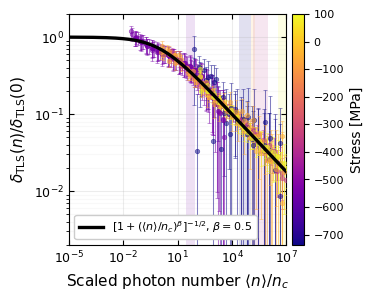

In [19]:
# =====================================================================
# Collapsed TLS saturation plot with stress-colored T_ref-to-1 K bands
#
# Requires:
#   power_results
#   temp_scaled_ranges          from Cell 1
#   _result_stress(...)
#   tls_tanh_factor(...)
#   T_BASE_POWER
# =====================================================================

def plot_tls_saturation_collapse_with_temp_bands(
    power_results,
    temp_scaled_ranges,
    figsize=(3.9, 3.2),
    cmap_name="plasma",
    n_fit_points=1000,
    beta_ref=None,
    band_alpha=0.12,
    band_edge_alpha=0.75,
    savepath=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib.lines import Line2D

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    stresses = np.asarray(
        [_result_stress(power_results[s]) for s in samples],
        dtype=float,
    )

    norm = mpl.colors.Normalize(
        vmin=np.nanmin(stresses),
        vmax=np.nanmax(stresses),
    )
    cmap = mpl.colormaps[cmap_name]

    fig, ax = plt.subplots(figsize=figsize)

    all_beta = []

    # -----------------------------------------------------------------
    # Collapse data
    # -----------------------------------------------------------------
    for sample in samples:
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        stress = _result_stress(result)
        color = cmap(norm(stress))

        A = float(tls["A_TLS"])
        nc = float(tls["nc"])
        beta = float(tls["beta"])

        all_beta.append(beta)

        for res_id, df_r in df_s.groupby("res_id"):
            df_r = df_r.sort_values("n")

            if res_id not in tls["C_res"]:
                continue

            Cj = float(tls["C_res"][res_id])
            f_res = float(df_r["f_res"].median())

            th = float(
                tls_tanh_factor(
                    T_BASE_POWER,
                    f_res,
                )
            )

            n = df_r["n"].to_numpy(float)
            invQ = df_r["invQ"].to_numpy(float)
            invQ_err = df_r["invQ_err"].to_numpy(float)

            x = n / nc
            y = (invQ - Cj) / (A * th)
            yerr = invQ_err / abs(A * th)

            good = (
                np.isfinite(x)
                & np.isfinite(y)
                & np.isfinite(yerr)
                & (x > 0)
                & (y > 0)
                & (yerr > 0)
            )

            ax.errorbar(
                x[good],
                y[good],
                yerr=yerr[good],
                fmt="o",
                ms=3.2,
                capsize=1.5,
                color=color,
                ecolor=color,
                alpha=0.52,
                elinewidth=0.75,
                markeredgewidth=0.55,
                zorder=4,
            )

    # -----------------------------------------------------------------
    # Stress-colored T_ref-to-1 K operating ranges
    # -----------------------------------------------------------------
    # Draw broad bands first and narrow bands last, reducing occlusion.
    band_rows = []

    for sample in samples:
        if sample not in temp_scaled_ranges:
            continue

        xlo, xhi = temp_scaled_ranges[sample]

        if not (
            np.isfinite(xlo)
            and np.isfinite(xhi)
            and xlo > 0
            and xhi > 0
        ):
            continue

        if xhi < xlo:
            xlo, xhi = xhi, xlo

        band_rows.append(
            (
                xhi / xlo,
                sample,
                xlo,
                xhi,
            )
        )

    # Broad first, narrow last
    band_rows.sort(reverse=True)

    for _, sample, xlo, xhi in band_rows:
        stress = _result_stress(power_results[sample])
        color = cmap(norm(stress))

        ax.axvspan(
            xlo,
            xhi,
            facecolor=color,
            edgecolor="none",
            alpha=band_alpha,
            zorder=1,
        )

        # ax.axvline(
        #     xlo,
        #     color=color,
        #     alpha=band_edge_alpha,
        #     linewidth=0.75, linestyle='--',
        #     zorder=2,
        # )

        # ax.axvline(
        #     xhi,
        #     color=color,
        #     alpha=band_edge_alpha,
        #     linewidth=0.75,linestyle='--',
        #     zorder=2,
        # )

    # -----------------------------------------------------------------
    # Universal TLS saturation curve
    # -----------------------------------------------------------------
    if beta_ref is None:
        beta_ref = float(np.nanmedian(all_beta))

    xplot = np.logspace(-5, 7, n_fit_points)

    yplot = 1.0 / np.sqrt(
        1.0 + xplot**beta_ref
    )

    ax.plot(
        xplot,
        yplot,
        color="black",
        lw=2.4,
        zorder=6,
        label=(
            rf"$[1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, "
            rf"$\beta={beta_ref:.2g}$"
        ),
    )

    # -----------------------------------------------------------------
    # Styling
    # -----------------------------------------------------------------
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Scaled photon number $\langle n\rangle/n_c$",
        fontsize=11,
    )
    ax.set_ylabel(
        r"$\delta_{\rm TLS}(n)/\delta_{\rm TLS}(0)$",
        fontsize=11,
    )

    ax.set_xlim(1e-5, 1e7)
    ax.set_ylim(2e-3, 2.0)

    ax.grid(
        True,
        which="major",
        alpha=0.24,
    )
    ax.grid(
        True,
        which="minor",
        alpha=0.08,
    )

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="in",
        top=True,
        right=True,
    )

    # Add one simple legend entry explaining the translucent bands.
    curve_handle = Line2D(
        [0],
        [0],
        color="black",
        lw=2.4,
        label=(
            rf"$[1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, "
            rf"$\beta={beta_ref:.2g}$"
        ),
    )

    band_handle = mpl.patches.Patch(
        facecolor="0.5",
        edgecolor="0.4",
        alpha=band_alpha,
        label=r"$T_{\rm ref}$--1 K ranges",
    )

    ax.legend(
        handles=[curve_handle],#, band_handle],
        fontsize=8,
        frameon=True,
        framealpha=1.0,
        loc="lower left",
        handlelength=2.2,
        borderpad=0.4,
    )

    sm = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.025,
        fraction=0.055,
    )
    cbar.set_label(
        "Stress [MPa]",
        fontsize=10,
    )
    cbar.ax.tick_params(
        labelsize=8,
    )

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(
            savepath,
            dpi=300,
            bbox_inches="tight",
        )

        if savepath.lower().endswith(".png"):
            fig.savefig(
                savepath[:-4] + ".pdf",
                bbox_inches="tight",
            )
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(
                savepath[:-4] + ".png",
                dpi=300,
                bbox_inches="tight",
            )

    return fig


fig = plot_tls_saturation_collapse_with_temp_bands(
    power_results,
    temp_scaled_ranges=temp_scaled_ranges,
    figsize=(3.9, 3.2),
    cmap_name="plasma",
    savepath="tls_saturation_collapse_temp_bands.pdf",
)

plt.show()

,sample,stress_MPa,temperature_mK,n_resonators,n_mean,n_err_lower,n_err_upper,S_mean,S_std
0,Sample A,-737.4,152.979412,3,999.063158,526.723666,1114.093184,0.063177,0.012344
1,Sample A,-737.4,205.838824,3,919.164794,501.518486,1103.752453,0.064565,0.013298
2,Sample A,-737.4,258.698235,3,929.083342,475.930106,975.781917,0.064251,0.012009
3,Sample A,-737.4,311.557647,3,930.769529,451.650625,877.407750,0.064114,0.011046
4,Sample A,-737.4,364.417059,3,901.620791,441.924770,866.765301,0.064642,0.011304


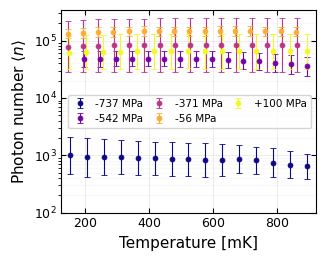

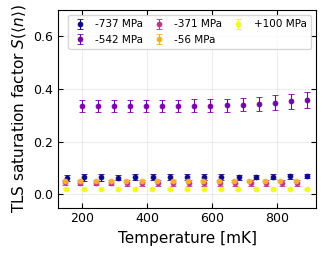

In [20]:
# =====================================================================
# Sample-averaged photon number and TLS saturation factor vs temperature
#
# Produces:
#   fig_n : <n>(T), averaged over resonators on each sample
#   fig_S : S(T), averaged over resonators on each sample
#
# Photon-number central value:
#   geometric mean across resonators
#
# Photon-number error bars:
#   ±1 standard deviation in log10(n), shown asymmetrically
#
# Saturation-factor central value:
#   arithmetic mean across resonators
#
# Saturation-factor error bars:
#   ±1 standard deviation across resonators
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


# ---------------------------------------------------------------------
# Experimental constants
# ---------------------------------------------------------------------

P_SOURCE_DBM = -10.0
ATTENUATION_DB = 96.0
P_DEVICE_DBM = P_SOURCE_DBM - ATTENUATION_DB

GAMMA_MISMATCH = 0.0
HALFWAVE = 0                    # 0 = quarter-wave, 1 = half-wave
H_PLANCK = 6.62607015e-34

T_MAX_MK = 1000
N_TEMPERATURE_POINTS = 18
MIN_RESONATORS_PER_POINT = 2


# ---------------------------------------------------------------------
# Photon-number and TLS functions
# ---------------------------------------------------------------------

def photon_number(
    pwr_dBm,
    f0_Hz,
    Q_loaded,
    Qc,
    gamma=GAMMA_MISMATCH,
    halfwave=HALFWAVE,
):
    """
    Calculate intra-resonator photon number using the convention
    employed in the existing temperature-sweep analysis.
    """
    pwr_W = 10.0**((float(pwr_dBm) - 30.0) / 10.0)

    f0_Hz = np.asarray(f0_Hz, dtype=float)
    Q_loaded = np.asarray(Q_loaded, dtype=float)
    Qc = np.asarray(Qc, dtype=float)

    factor_P = 2 - halfwave
    factor_N = 4 - 2 * halfwave

    P_int = (
        (1.0 - gamma**2)
        * factor_P
        * Q_loaded**2
        / (np.pi * Qc)
        * pwr_W
    )

    return P_int / (
        factor_N * H_PLANCK * f0_Hz**2
    )


def tls_saturation_factor(n, nc, beta):
    """
    S(n) = [1 + (n/nc)^beta]^(-1/2)
    """
    n = np.asarray(n, dtype=float)

    return 1.0 / np.sqrt(
        1.0 + (n / float(nc))**float(beta)
    )


# ---------------------------------------------------------------------
# Extract per-resonator n(T) and S(T)
# ---------------------------------------------------------------------

curve_rows = []

for sample, chip in stress_resonators.items():

    if sample == "All Film":
        continue

    if not isinstance(chip, dict):
        continue

    if sample not in power_results:
        continue

    stress = float(
        chip.get(
            "stress",
            _result_stress(power_results[sample]),
        )
    )

    tls = power_results[sample]["tls_saturation"]
    nc = float(tls["nc"])
    beta = float(tls["beta"])

    for res_name, rd in chip.items():

        if not isinstance(rd, dict):
            continue

        required = {
            "Temp",
            "Qi_Temp",
            "Qc_Temp",
            "Freq",
        }

        if not required.issubset(rd):
            continue

        T = np.asarray(rd["Temp"], dtype=float)
        Qi = np.asarray(rd["Qi_Temp"], dtype=float)
        Qc = np.asarray(rd["Qc_Temp"], dtype=float)
        freq = np.asarray(rd["Freq"], dtype=float)

        # Broadcast scalar frequency if needed.
        if freq.ndim == 0 or freq.size == 1:
            freq = np.full_like(
                T,
                float(freq.ravel()[0]),
                dtype=float,
            )

        npts = min(
            len(T),
            len(Qi),
            len(Qc),
            len(freq),
        )

        T = T[:npts]
        Qi = Qi[:npts]
        Qc = Qc[:npts]
        freq = freq[:npts]

        good = (
            np.isfinite(T)
            & np.isfinite(Qi)
            & np.isfinite(Qc)
            & np.isfinite(freq)
            & (Qi > 0)
            & (Qc > 0)
            & (freq > 0)
            & (T <= T_MAX_MK)
        )

        if np.count_nonzero(good) < 2:
            continue

        T = T[good]
        Qi = Qi[good]
        Qc = Qc[good]
        freq = freq[good]

        order = np.argsort(T)

        T = T[order]
        Qi = Qi[order]
        Qc = Qc[order]
        freq = freq[order]

        # Remove duplicate temperatures before interpolation.
        T_unique, unique_indices = np.unique(
            T,
            return_index=True,
        )

        T = T_unique
        Qi = Qi[unique_indices]
        Qc = Qc[unique_indices]
        freq = freq[unique_indices]

        if len(T) < 2:
            continue

        Q_loaded = 1.0 / (
            1.0 / Qi + 1.0 / Qc
        )

        n_photon = photon_number(
            P_DEVICE_DBM,
            freq,
            Q_loaded,
            Qc,
        )

        S = tls_saturation_factor(
            n_photon,
            nc,
            beta,
        )

        for Ti, ni, Si in zip(T, n_photon, S):
            curve_rows.append({
                "sample": sample,
                "resonator": res_name,
                "stress_MPa": stress,
                "temperature_mK": float(Ti),
                "photon_number": float(ni),
                "S": float(Si),
                "nc": nc,
                "beta": beta,
            })


photon_temperature_curves = pd.DataFrame(curve_rows)

if photon_temperature_curves.empty:
    raise RuntimeError(
        "No valid temperature-sweep curves were found."
    )


# ---------------------------------------------------------------------
# Interpolate resonators in each sample onto a common temperature grid
# ---------------------------------------------------------------------

summary_rows = []

samples = sorted(
    photon_temperature_curves["sample"].unique(),
    key=lambda s: photon_temperature_curves.loc[
        photon_temperature_curves["sample"] == s,
        "stress_MPa",
    ].iloc[0],
)

for sample in samples:

    df_s = photon_temperature_curves[
        photon_temperature_curves["sample"] == sample
    ]

    resonator_curves = []

    for res_name, df_r in df_s.groupby("resonator"):

        df_r = df_r.sort_values("temperature_mK")

        T = df_r["temperature_mK"].to_numpy(float)
        n = df_r["photon_number"].to_numpy(float)
        S = df_r["S"].to_numpy(float)

        good = (
            np.isfinite(T)
            & np.isfinite(n)
            & np.isfinite(S)
            & (n > 0)
        )

        T = T[good]
        n = n[good]
        S = S[good]

        if len(T) < 2:
            continue

        resonator_curves.append({
            "resonator": res_name,
            "T": T,
            "n": n,
            "S": S,
        })

    if not resonator_curves:
        continue

    # Only use temperatures covered by at least some resonators.
    sample_T_min = min(
        curve["T"].min()
        for curve in resonator_curves
    )

    sample_T_max = min(
        T_MAX_MK,
        max(
            curve["T"].max()
            for curve in resonator_curves
        ),
    )

    T_grid = np.linspace(
        sample_T_min,
        sample_T_max,
        N_TEMPERATURE_POINTS,
    )

    stress = float(
        df_s["stress_MPa"].iloc[0]
    )

    for T_eval in T_grid:

        n_values = []
        S_values = []

        for curve in resonator_curves:

            # Do not extrapolate beyond this resonator's measured range.
            if (
                T_eval < curve["T"].min()
                or T_eval > curve["T"].max()
            ):
                continue

            # Interpolate photon number in log space.
            log10_n_interp = np.interp(
                T_eval,
                curve["T"],
                np.log10(curve["n"]),
            )

            n_interp = 10.0**log10_n_interp

            # S is smooth and bounded, so interpolate linearly.
            S_interp = np.interp(
                T_eval,
                curve["T"],
                curve["S"],
            )

            if np.isfinite(n_interp) and n_interp > 0:
                n_values.append(n_interp)

            if np.isfinite(S_interp):
                S_values.append(S_interp)

        n_values = np.asarray(n_values, dtype=float)
        S_values = np.asarray(S_values, dtype=float)

        if (
            len(n_values) < MIN_RESONATORS_PER_POINT
            or len(S_values) < MIN_RESONATORS_PER_POINT
        ):
            continue

        # Geometric mean and log-space standard deviation for n.
        log10_n = np.log10(n_values)

        log10_n_mean = np.nanmean(log10_n)
        log10_n_std = np.nanstd(
            log10_n,
            ddof=1 if len(log10_n) > 1 else 0,
        )

        n_center = 10.0**log10_n_mean
        n_lower = 10.0**(
            log10_n_mean - log10_n_std
        )
        n_upper = 10.0**(
            log10_n_mean + log10_n_std
        )

        # Arithmetic mean and standard deviation for S.
        S_center = np.nanmean(S_values)
        S_std = np.nanstd(
            S_values,
            ddof=1 if len(S_values) > 1 else 0,
        )

        summary_rows.append({
            "sample": sample,
            "stress_MPa": stress,
            "temperature_mK": T_eval,
            "n_resonators": len(n_values),

            "n_mean": n_center,
            "n_err_lower": n_center - n_lower,
            "n_err_upper": n_upper - n_center,

            "S_mean": S_center,
            "S_std": S_std,
        })


temperature_average_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(
        ["stress_MPa", "temperature_mK"]
    )
    .reset_index(drop=True)
)

display(temperature_average_summary.head())


# ---------------------------------------------------------------------
# Shared colors: one color per film stress
# ---------------------------------------------------------------------

stresses = np.asarray(
    [
        temperature_average_summary.loc[
            temperature_average_summary["sample"] == sample,
            "stress_MPa",
        ].iloc[0]
        for sample in samples
        if sample in temperature_average_summary["sample"].values
    ],
    dtype=float,
)

norm = mpl.colors.Normalize(
    vmin=np.nanmin(stresses),
    vmax=np.nanmax(stresses),
)

cmap = mpl.colormaps["plasma"]


# =====================================================================
# Plot 1: sample-averaged photon number vs temperature
# =====================================================================

fig_n, ax_n = plt.subplots(
    figsize=(3.45, 2.8)
)

for sample in samples:

    df_plot = temperature_average_summary[
        temperature_average_summary["sample"] == sample
    ]

    if df_plot.empty:
        continue

    stress = float(
        df_plot["stress_MPa"].iloc[0]
    )

    color = cmap(norm(stress))

    yerr = np.vstack([
        df_plot["n_err_lower"].to_numpy(float),
        df_plot["n_err_upper"].to_numpy(float),
    ])

    ax_n.errorbar(
        df_plot["temperature_mK"],
        df_plot["n_mean"],
        yerr=yerr,
        fmt="o",
        ms=3.5,
        lw=1.4,
        capsize=2.0,
        color=color,
        ecolor=color,
        elinewidth=0.8,
        markeredgewidth=0.6,
        label=f"{stress:+.0f} MPa",
        zorder=4,
    )

ax_n.set_yscale("log")
ax_n.set_xlim(
    temperature_average_summary["temperature_mK"].min()-20,
    920,
)
ax_n.set_ylim(1e2)

ax_n.set_xlabel(
    "Temperature [mK]",
    fontsize=11,
)
ax_n.set_ylabel(
    r"Photon number $\langle n\rangle$",
    fontsize=11,
)

ax_n.grid(
    True,
    which="major",
    alpha=0.22,
)
ax_n.grid(
    True,
    which="minor",
    alpha=0.08,
)

ax_n.tick_params(
    axis="both",
    labelsize=9,
    direction="in",
    top=True,
    right=True,
)

ax_n.legend(
    fontsize=7.5,
    frameon=True,
    ncol=3,
    loc="best",
    handlelength=1.4,
    columnspacing=0.8,
)

fig_n.tight_layout()

fig_n.savefig(
    "photon_number_vs_temperature_to_900mK.pdf",
    bbox_inches="tight",
)
fig_n.savefig(
    "photon_number_vs_temperature_to_900mK.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# =====================================================================
# Plot 2: sample-averaged TLS saturation factor vs temperature
# =====================================================================

fig_S, ax_S = plt.subplots(
    figsize=(3.45, 2.8)
)

for sample in samples:

    df_plot = temperature_average_summary[
        temperature_average_summary["sample"] == sample
    ]

    if df_plot.empty:
        continue

    stress = float(
        df_plot["stress_MPa"].iloc[0]
    )

    color = cmap(norm(stress))

    # Clip lower errors so the error bar never extends below S = 0.
    lower_err = np.minimum(
        df_plot["S_std"].to_numpy(float),
        df_plot["S_mean"].to_numpy(float),
    )

    upper_err = np.minimum(
        df_plot["S_std"].to_numpy(float),
        1.0 - df_plot["S_mean"].to_numpy(float),
    )

    yerr = np.vstack([
        lower_err,
        upper_err,
    ])

    ax_S.errorbar(
        df_plot["temperature_mK"],
        df_plot["S_mean"],
        yerr=yerr,
        fmt="o",
        ms=3.5,
        lw=1.4,
        capsize=2.0,
        color=color,
        ecolor=color,
        elinewidth=0.8,
        markeredgewidth=0.6,
        label=f"{stress:+.0f} MPa",
        zorder=4,
    )

ax_S.set_xlim(
    temperature_average_summary["temperature_mK"].min() - 20,
    900 + 20,
)

# Let the data choose a useful lower limit while keeping the physical
# upper limit visible.
S_min_plot = np.nanmin(
    temperature_average_summary["S_mean"]
    - temperature_average_summary["S_std"]
)

ax_S.set_ylim(
    -.05,
    .7,
)

ax_S.set_xlabel(
    "Temperature [mK]",
    fontsize=11,
)
ax_S.set_ylabel(
    r"TLS saturation factor $S(\langle n\rangle)$",
    fontsize=11,
)

ax_S.grid(
    True,
    which="major",
    alpha=0.22,
)

ax_S.tick_params(
    axis="both",
    labelsize=9,
    direction="in",
    top=True,
    right=True,
)

ax_S.legend(
    fontsize=7.5,
    frameon=True,
    ncol=3,
    loc="best",
    handlelength=1.4,
    columnspacing=0.8,
)

fig_S.tight_layout()

fig_S.savefig(
    "tls_saturation_factor_vs_temperature_to_900mK.pdf",
    bbox_inches="tight",
)
fig_S.savefig(
    "tls_saturation_factor_vs_temperature_to_900mK.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Operating ranges used in the plot:


,sample,stress,n_resonators,x_min,x_max,median_S_percent_change,max_abs_S_percent_change
0,Sample A,-737.4,3,1.847169e+04,1.164404e+05,23.608716,24.365940
1,Sample B,-542.3,4,2.304774e+01,8.699112e+01,10.804780,14.137497
2,Sample C,-371.3,3,1.393248e+05,9.673387e+05,-0.876555,4.292590
3,Sample D,-56.3,4,1.115072e+05,1.859786e+05,-2.442941,3.660746
4,Sample E,100.3,3,3.516410e+06,1.336205e+07,-0.838615,3.631179


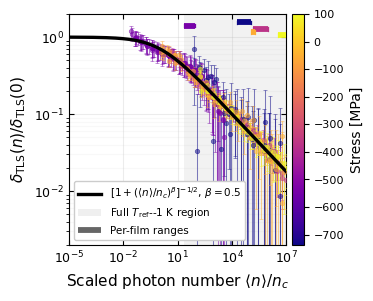

In [21]:
# =====================================================================
# TLS collapse with sample-specific T_ref-to-1 K operating intervals
#
# Requires:
#   stress_resonators
#   power_results
#   _result_stress(...)
#   tls_tanh_factor(...)
#   T_BASE_POWER
#
# Uses:
#   P_device = -10 dBm source - 96 dB attenuation
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------
# User-adjustable settings
# ---------------------------------------------------------------------

P_DEVICE_DBM = -10.0 - 96.0
GAMMA = 0.0
HALFWAVE = 0                       # 0 = quarter-wave
H_PLANCK = 6.62607015e-34

T_RANGE_MAX_MK = 1000.0
T_TOLERANCE_MK = 75.0

CMAP_NAME = "plasma"
FIGSIZE = (3.9, 3.2)
N_FIT_POINTS = 1000

X_LIMITS = (1e-5, 1e7)
Y_LIMITS = (2e-3, 2.0)

SAVE_PATH = "tls_saturation_collapse_operating_ranges.pdf"


# ---------------------------------------------------------------------
# Physics helpers
# ---------------------------------------------------------------------

def _photon_number_temperature_sweep(
    pwr_dBm,
    f0_Hz,
    Q_loaded,
    Qc,
    gamma=GAMMA,
    halfwave=HALFWAVE,
):
    """
    Intra-resonator photon number using the convention employed
    in the temperature-sweep analysis.
    """
    pwr_W = 10.0**((float(pwr_dBm) - 30.0) / 10.0)

    f0_Hz = np.asarray(f0_Hz, dtype=float)
    Q_loaded = np.asarray(Q_loaded, dtype=float)
    Qc = np.asarray(Qc, dtype=float)

    factor_P = 2 - halfwave
    factor_N = 4 - 2 * halfwave

    P_int = (
        (1.0 - gamma**2)
        * factor_P
        * Q_loaded**2
        / (np.pi * Qc)
        * pwr_W
    )

    return P_int / (
        factor_N * H_PLANCK * f0_Hz**2
    )


def _tls_saturation_factor(n, nc, beta):
    """
    S(n) = [1 + (n/nc)^beta]^(-1/2)
    """
    n = np.asarray(n, dtype=float)

    return 1.0 / np.sqrt(
        1.0 + (n / float(nc))**float(beta)
    )


# ---------------------------------------------------------------------
# Extract each sample's scaled photon-number range from T_ref to 1 K
# ---------------------------------------------------------------------

temperature_rows = []

for sample, chip in stress_resonators.items():

    if sample == "All Film" or not isinstance(chip, dict):
        continue

    if sample not in power_results:
        continue

    stress = float(
        chip.get(
            "stress",
            _result_stress(power_results[sample]),
        )
    )

    tls = power_results[sample]["tls_saturation"]
    nc = float(tls["nc"])
    beta = float(tls["beta"])

    for resonator, rd in chip.items():

        if not isinstance(rd, dict):
            continue

        required = {
            "Temp",
            "Qi_Temp",
            "Qc_Temp",
            "Freq",
        }

        if not required.issubset(rd):
            continue

        T = np.asarray(rd["Temp"], dtype=float)
        Qi = np.asarray(rd["Qi_Temp"], dtype=float)
        Qc = np.asarray(rd["Qc_Temp"], dtype=float)
        freq = np.asarray(rd["Freq"], dtype=float)

        # Broadcast scalar frequency if necessary.
        if freq.ndim == 0 or freq.size == 1:
            freq = np.full_like(
                T,
                float(freq.ravel()[0]),
                dtype=float,
            )

        npts = min(
            len(T),
            len(Qi),
            len(Qc),
            len(freq),
        )

        T = T[:npts]
        Qi = Qi[:npts]
        Qc = Qc[:npts]
        freq = freq[:npts]

        good = (
            np.isfinite(T)
            & np.isfinite(Qi)
            & np.isfinite(Qc)
            & np.isfinite(freq)
            & (Qi > 0)
            & (Qc > 0)
            & (freq > 0)
            & (T <= T_RANGE_MAX_MK + T_TOLERANCE_MK)
        )

        if np.count_nonzero(good) < 2:
            continue

        T = T[good]
        Qi = Qi[good]
        Qc = Qc[good]
        freq = freq[good]

        order = np.argsort(T)

        T = T[order]
        Qi = Qi[order]
        Qc = Qc[order]
        freq = freq[order]

        # Remove duplicate temperature entries.
        T, unique_idx = np.unique(
            T,
            return_index=True,
        )

        Qi = Qi[unique_idx]
        Qc = Qc[unique_idx]
        freq = freq[unique_idx]

        if len(T) < 2:
            continue

        # Require a point reasonably close to 1 K.
        i_1K = int(
            np.argmin(
                np.abs(T - T_RANGE_MAX_MK)
            )
        )

        if (
            abs(T[i_1K] - T_RANGE_MAX_MK)
            > T_TOLERANCE_MK
        ):
            continue

        # Restrict explicitly from the lowest temperature
        # through the selected point near 1 K.
        use = np.arange(len(T)) <= i_1K

        T = T[use]
        Qi = Qi[use]
        Qc = Qc[use]
        freq = freq[use]

        Q_loaded = 1.0 / (
            1.0 / Qi + 1.0 / Qc
        )

        n_photon = _photon_number_temperature_sweep(
            P_DEVICE_DBM,
            freq,
            Q_loaded,
            Qc,
        )

        S = _tls_saturation_factor(
            n_photon,
            nc,
            beta,
        )

        scaled_n = n_photon / nc

        valid = (
            np.isfinite(n_photon)
            & np.isfinite(S)
            & np.isfinite(scaled_n)
            & (n_photon > 0)
            & (scaled_n > 0)
        )

        if np.count_nonzero(valid) < 2:
            continue

        temperature_rows.append({
            "sample": sample,
            "resonator": resonator,
            "stress": stress,
            "nc": nc,
            "beta": beta,

            "T_ref_mK": float(T[valid][0]),
            "T_high_mK": float(T[valid][-1]),

            "x_min": float(
                np.nanmin(scaled_n[valid])
            ),
            "x_max": float(
                np.nanmax(scaled_n[valid])
            ),

            "S_ref": float(S[valid][0]),
            "S_high": float(S[valid][-1]),

            "S_percent_change": float(
                100.0
                * (
                    S[valid][-1]
                    / S[valid][0]
                    - 1.0
                )
            ),
        })


if not temperature_rows:
    raise RuntimeError(
        "No valid temperature-sweep resonators were found."
    )


temperature_operating_ranges = pd.DataFrame(
    temperature_rows
)

sample_operating_ranges = (
    temperature_operating_ranges
    .groupby("sample", as_index=False)
    .agg(
        stress=("stress", "first"),
        n_resonators=("resonator", "nunique"),
        x_min=("x_min", "min"),
        x_max=("x_max", "max"),
        median_S_percent_change=(
            "S_percent_change",
            "median",
        ),
        max_abs_S_percent_change=(
            "S_percent_change",
            lambda x: np.nanmax(np.abs(x)),
        ),
    )
    .sort_values("stress")
    .reset_index(drop=True)
)

print("Operating ranges used in the plot:")
display(sample_operating_ranges)


# ---------------------------------------------------------------------
# Prepare collapse figure
# ---------------------------------------------------------------------

samples = sorted(
    power_results.keys(),
    key=lambda s: _result_stress(
        power_results[s]
    ),
)

# Exclude any non-sample entries that lack fit data.
samples = [
    sample
    for sample in samples
    if (
        isinstance(power_results[sample], dict)
        and "data" in power_results[sample]
        and "tls_saturation" in power_results[sample]
    )
]

stresses = np.asarray(
    [
        _result_stress(
            power_results[sample]
        )
        for sample in samples
    ],
    dtype=float,
)

norm = mpl.colors.Normalize(
    vmin=np.nanmin(stresses),
    vmax=np.nanmax(stresses),
)

cmap = mpl.colormaps[CMAP_NAME]

fig, ax = plt.subplots(
    figsize=FIGSIZE
)

all_beta = []


# ---------------------------------------------------------------------
# Plot collapsed power-sweep points
# ---------------------------------------------------------------------

for sample in samples:

    result = power_results[sample]
    df_s = result["data"]
    tls = result["tls_saturation"]

    stress = _result_stress(result)
    color = cmap(norm(stress))

    A = float(tls["A_TLS"])
    nc = float(tls["nc"])
    beta = float(tls["beta"])

    all_beta.append(beta)

    for res_id, df_r in df_s.groupby(
        "res_id"
    ):
        df_r = df_r.sort_values("n")

        if res_id not in tls["C_res"]:
            continue

        Cj = float(
            tls["C_res"][res_id]
        )

        f_res = float(
            df_r["f_res"].median()
        )

        th = float(
            tls_tanh_factor(
                T_BASE_POWER,
                f_res,
            )
        )

        n = df_r["n"].to_numpy(float)
        invQ = df_r["invQ"].to_numpy(float)
        invQ_err = df_r[
            "invQ_err"
        ].to_numpy(float)

        x = n / nc
        y = (invQ - Cj) / (A * th)
        yerr = invQ_err / abs(A * th)

        good = (
            np.isfinite(x)
            & np.isfinite(y)
            & np.isfinite(yerr)
            & (x > 0)
            & (y > 0)
            & (yerr > 0)
        )

        ax.errorbar(
            x[good],
            y[good],
            yerr=yerr[good],
            fmt="o",
            ms=3.2,
            capsize=1.5,
            color=color,
            ecolor=color,
            alpha=0.52,
            elinewidth=0.75,
            markeredgewidth=0.55,
            zorder=4,
        )


# ---------------------------------------------------------------------
# Plot the universal TLS saturation curve
# ---------------------------------------------------------------------

beta_ref = float(
    np.nanmedian(all_beta)
)

x_curve = np.logspace(
    np.log10(X_LIMITS[0]),
    np.log10(X_LIMITS[1]),
    N_FIT_POINTS,
)

y_curve = 1.0 / np.sqrt(
    1.0 + x_curve**beta_ref
)

ax.plot(
    x_curve,
    y_curve,
    color="black",
    lw=2.4,
    zorder=6,
)


# ---------------------------------------------------------------------
# Plot sample-specific operating intervals
# ---------------------------------------------------------------------
#
# These are placed in the upper part of the panel and vertically
# staggered so that overlapping x-ranges remain distinguishable.
# ---------------------------------------------------------------------

range_rows = []

for _, row in sample_operating_ranges.iterrows():

    sample = row["sample"]

    if sample not in samples:
        continue

    xlo = float(row["x_min"])
    xhi = float(row["x_max"])

    if not (
        np.isfinite(xlo)
        and np.isfinite(xhi)
        and xlo > 0
        and xhi > 0
    ):
        continue

    if xhi < xlo:
        xlo, xhi = xhi, xlo

    range_rows.append({
        "sample": sample,
        "stress": float(row["stress"]),
        "xlo": xlo,
        "xhi": xhi,
    })


# Arrange in stress order, using multiplicative y spacing
# because the plot has a logarithmic y axis.
range_rows = sorted(
    range_rows,
    key=lambda row: row["stress"],
)

range_y_positions = np.geomspace(
    1.55,
    1.06,
    len(range_rows),
)

for range_row, y_pos in zip(
    range_rows,
    range_y_positions,
):
    sample = range_row["sample"]
    stress = range_row["stress"]
    xlo = range_row["xlo"]
    xhi = range_row["xhi"]

    color = cmap(norm(stress))

    # Main horizontal interval
    ax.plot(
        [xlo, xhi],
        [y_pos, y_pos],
        color=color,
        lw=4.2,
        solid_capstyle="butt",
        zorder=9,
    )

    # End caps
    cap_low = y_pos / 1.055
    cap_high = y_pos * 1.055

    ax.plot(
        [xlo, xlo],
        [cap_low, cap_high],
        color=color,
        lw=0.9,
        zorder=9,
    )

    ax.plot(
        [xhi, xhi],
        [cap_low, cap_high],
        color=color,
        lw=0.9,
        zorder=9,
    )


# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(*X_LIMITS)
ax.set_ylim(*Y_LIMITS)

ax.set_xlabel(
    r"Scaled photon number "
    r"$\langle n\rangle/n_c$",
    fontsize=11,
)

ax.set_ylabel(
    r"$\delta_{\rm TLS}(n)"
    r"/\delta_{\rm TLS}(0)$",
    fontsize=11,
)

ax.grid(
    True,
    which="major",
    alpha=0.24,
)

ax.grid(
    True,
    which="minor",
    alpha=0.08,
)

ax.tick_params(
    axis="both",
    labelsize=9,
    direction="in",
    top=True,
    right=True,
)

# ---------------------------------------------------------------------
# Very faint global operating region
# ---------------------------------------------------------------------
# This spans the full minimum-to-maximum scaled photon-number range
# sampled by any film between T_ref and 1 K. The colored intervals below
# retain the sample-specific information.

global_x_min = float(
    np.nanmin(sample_operating_ranges["x_min"])
)

global_x_max = float(
    np.nanmax(sample_operating_ranges["x_max"])
)

ax.axvspan(
    global_x_min,
    global_x_max,
    facecolor="0.5",
    edgecolor="none",
    alpha=0.1,   # intentionally very faint
    zorder=0,
)

# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------

curve_handle = Line2D(
    [0],
    [0],
    color="black",
    lw=2.4,
    label=(
        rf"$[1+(\langle n\rangle/n_c)"
        rf"^{{\beta}}]^{{-1/2}}$, "
        rf"$\beta={beta_ref:.2g}$"
    ),
)

global_range_handle = mpl.patches.Patch(
    facecolor="0.5",
    edgecolor="none",
    alpha=0.12,  # stronger in legend so the symbol remains visible
    label=r"Full $T_{\rm ref}$--1 K region",
)

sample_range_handle = Line2D(
    [0],
    [0],
    color="0.4",
    lw=4.2,
    solid_capstyle="butt",
    label="Per-film ranges",
)

ax.legend(
    handles=[
        curve_handle,
        global_range_handle,
        sample_range_handle,
    ],
    fontsize=7.5,
    frameon=True,
    framealpha=1.0,
    loc="lower left",
    handlelength=2.2,
    borderpad=0.4,
)


# ---------------------------------------------------------------------
# Stress colorbar
# ---------------------------------------------------------------------

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.025,
    fraction=0.055,
)

cbar.set_label(
    "Stress [MPa]",
    fontsize=10,
)

cbar.ax.tick_params(
    labelsize=8,
)


fig.tight_layout()

if SAVE_PATH is not None:

    fig.savefig(
        SAVE_PATH,
        bbox_inches="tight",
    )

    if SAVE_PATH.lower().endswith(
        ".pdf"
    ):
        fig.savefig(
            SAVE_PATH[:-4] + ".png",
            dpi=300,
            bbox_inches="tight",
        )

    elif SAVE_PATH.lower().endswith(
        ".png"
    ):
        fig.savefig(
            SAVE_PATH[:-4] + ".pdf",
            bbox_inches="tight",
        )

plt.show()

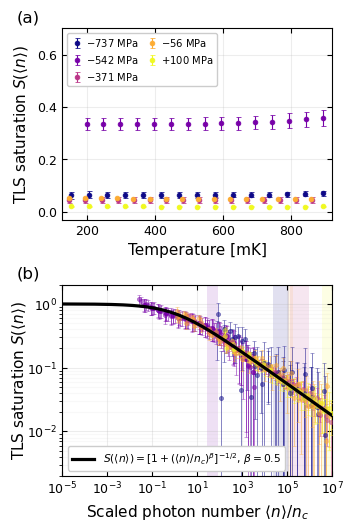

In [40]:
# =====================================================================
# Stacked TLS figure
#
# (a) Collapsed TLS power-sweep data with T_ref--1 K operating ranges
# (b) Sample-averaged TLS saturation factor versus temperature
#
# Requires:
#   power_results
#   temp_scaled_ranges
#   temperature_average_summary
#   _result_stress(...)
#   tls_tanh_factor(...)
#   T_BASE_POWER
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------
# Figure settings
# ---------------------------------------------------------------------

CMAP_NAME = "plasma"
FIGSIZE = (4.15, 5)

N_FIT_POINTS = 1000
BAND_ALPHA = 0.12

SAVE_PATH = "tls_collapse_and_temperature_dependence.pdf"


# ---------------------------------------------------------------------
# Select and sort samples
# ---------------------------------------------------------------------

samples = sorted(
    [
        sample
        for sample, result in power_results.items()
        if (
            isinstance(result, dict)
            and "data" in result
            and "tls_saturation" in result
        )
    ],
    key=lambda sample: _result_stress(power_results[sample]),
)

stresses = np.asarray(
    [
        _result_stress(power_results[sample])
        for sample in samples
    ],
    dtype=float,
)

norm = mpl.colors.Normalize(
    vmin=np.nanmin(stresses),
    vmax=np.nanmax(stresses),
)

cmap = mpl.colormaps[CMAP_NAME]


# ---------------------------------------------------------------------
# Create stacked figure
# ---------------------------------------------------------------------

fig, axs = plt.subplots(
    2,
    1,
    figsize=FIGSIZE,
    constrained_layout=False,
)

ax_temp, ax_collapse = axs


# =====================================================================
# Panel (a): collapsed TLS saturation plot
# =====================================================================

all_beta = []

for sample in samples:

    result = power_results[sample]
    df_s = result["data"]
    tls = result["tls_saturation"]

    stress = _result_stress(result)
    color = cmap(norm(stress))

    A = float(tls["A_TLS"])
    nc = float(tls["nc"])
    beta = float(tls["beta"])

    all_beta.append(beta)

    for res_id, df_r in df_s.groupby("res_id"):

        df_r = df_r.sort_values("n")

        if res_id not in tls["C_res"]:
            continue

        Cj = float(tls["C_res"][res_id])
        f_res = float(df_r["f_res"].median())

        th = float(
            tls_tanh_factor(
                T_BASE_POWER,
                f_res,
            )
        )

        n = df_r["n"].to_numpy(float)
        invQ = df_r["invQ"].to_numpy(float)
        invQ_err = df_r["invQ_err"].to_numpy(float)

        x = n / nc
        y = (invQ - Cj) / (A * th)
        yerr = invQ_err / abs(A * th)

        good = (
            np.isfinite(x)
            & np.isfinite(y)
            & np.isfinite(yerr)
            & (x > 0)
            & (y > 0)
            & (yerr > 0)
        )

        ax_collapse.errorbar(
            x[good],
            y[good],
            yerr=yerr[good],
            fmt="o",
            ms=3.0,
            capsize=1.4,
            color=color,
            ecolor=color,
            alpha=0.50,
            elinewidth=0.7,
            markeredgewidth=0.5,
            zorder=4,
        )


# ---------------------------------------------------------------------
# Sample-specific T_ref--1 K operating ranges
# ---------------------------------------------------------------------

band_rows = []

for sample in samples:

    if sample not in temp_scaled_ranges:
        continue

    xlo, xhi = temp_scaled_ranges[sample]

    if not (
        np.isfinite(xlo)
        and np.isfinite(xhi)
        and xlo > 0
        and xhi > 0
    ):
        continue

    if xhi < xlo:
        xlo, xhi = xhi, xlo

    band_rows.append(
        (
            xhi / xlo,
            sample,
            xlo,
            xhi,
        )
    )

# Draw broad ranges first.
band_rows.sort(reverse=True)

for _, sample, xlo, xhi in band_rows:

    stress = _result_stress(power_results[sample])
    color = cmap(norm(stress))

    ax_collapse.axvspan(
        xlo,
        xhi,
        facecolor=color,
        edgecolor="none",
        alpha=BAND_ALPHA,
        zorder=1,
    )


# ---------------------------------------------------------------------
# Universal TLS saturation curve
# ---------------------------------------------------------------------

beta_ref = float(np.nanmedian(all_beta))

xplot = np.logspace(
    -5,
    7,
    N_FIT_POINTS,
)

yplot = 1.0 / np.sqrt(
    1.0 + xplot**beta_ref
)

ax_collapse.plot(
    xplot,
    yplot,
    color="black",
    lw=2.3,
    zorder=6,
)


# ---------------------------------------------------------------------
# Panel (a) styling
# ---------------------------------------------------------------------

ax_collapse.set_xscale("log")
ax_collapse.set_yscale("log")

ax_collapse.set_xlim(1e-5, 1e7)
ax_collapse.set_ylim(2e-3, 2.0)

ax_collapse.set_xlabel(
    r"Scaled photon number $\langle n\rangle/n_c$",
    fontsize=11,
)

ax_collapse.set_ylabel(
    r"TLS saturation $S(\langle n\rangle)$",
    fontsize=11,
    labelpad=-.5
)

ax_collapse.grid(
    True,
    which="major",
    alpha=0.24,
)

ax_collapse.grid(
    True,
    which="minor",
    alpha=0.08,
)

ax_collapse.tick_params(
    axis="both",
    labelsize=9,
    direction="in",
    top=True,
    right=True,
)


curve_handle = Line2D(
    [0],
    [0],
    color="black",
    lw=2.3,
    label=(
        rf"$S(\langle n\rangle) = [1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, "
        rf"$\beta={beta_ref:.2g}$"
    ),
)

band_handle = mpl.patches.Patch(
    facecolor="0.5",
    edgecolor="none",
    alpha=0.16,
    label=r"$T_{\rm ref}$--1 K ranges",
)

ax_collapse.legend(
    handles=[
        curve_handle,
    ],
    fontsize=7.7,
    frameon=True,
    framealpha=1.0,
    loc="lower left",
    handlelength=2.1,
    borderpad=0.4,
)


# =====================================================================
# Panel (b): average TLS saturation factor versus temperature
# =====================================================================

for sample in samples:

    df_plot = temperature_average_summary[
        temperature_average_summary["sample"] == sample
    ].sort_values("temperature_mK")

    if df_plot.empty:
        continue

    stress = float(
        df_plot["stress_MPa"].iloc[0]
    )

    color = cmap(norm(stress))

    S_mean = df_plot["S_mean"].to_numpy(float)
    S_std = df_plot["S_std"].to_numpy(float)

    # Prevent error bars from extending outside 0 <= S <= 1.
    lower_err = np.minimum(
        S_std,
        S_mean,
    )

    upper_err = np.minimum(
        S_std,
        1.0 - S_mean,
    )

    yerr = np.vstack([
        lower_err,
        upper_err,
    ])

    ax_temp.errorbar(
        df_plot["temperature_mK"],
        S_mean,
        yerr=yerr,
        fmt="o",
        ms=3.4,
        capsize=1.8,
        color=color,
        ecolor=color,
        elinewidth=0.8,
        markeredgewidth=0.55,
        label=f"${stress:+.0f}$ MPa",
        zorder=4,
    )


# ---------------------------------------------------------------------
# Panel (b) styling
# ---------------------------------------------------------------------

ax_temp.set_xlim(
    temperature_average_summary["temperature_mK"].min() - 20,
    920,
)

ax_temp.set_ylim(
    -0.03,
    0.70,
)

ax_temp.set_xlabel(
    "Temperature [mK]",
    fontsize=11,
)

ax_temp.set_ylabel(
    r"TLS saturation $S(\langle n\rangle)$",
    fontsize=11,
    labelpad=5
)

ax_temp.grid(
    True,
    which="major",
    alpha=0.22,
)

ax_temp.tick_params(
    axis="both",
    labelsize=9,
    direction="in",
    top=True,
    right=True,
)

ax_temp.legend(
    fontsize=7.2,
    frameon=True,
    framealpha=1.0,
    ncol=2,
    loc="upper left",
    handlelength=1.2,
    columnspacing=0.7,
    handletextpad=0.35,
    borderpad=0.35,
)


# =====================================================================
# Panel labels
# =====================================================================

ax_collapse.text(
    -0.17,
    1.02,
    "(b)",
    transform=ax_collapse.transAxes,
    fontsize=12,
    va="bottom",
    ha="left",
)

ax_temp.text(
    -0.17,
    1.02,
    "(a)",
    transform=ax_temp.transAxes,
    fontsize=12,
    va="bottom",
    ha="left",
)


# =====================================================================
# Shared stress colorbar
# =====================================================================

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

# cbar = fig.colorbar(
#     sm,
#     ax=axs,
#     orientation="vertical",
#     pad=0.025,
#     fraction=0.045,
#     aspect=35,
# )

# cbar.set_label(
#     "Stress [MPa]",
#     fontsize=10,
# )

# cbar.ax.tick_params(
#     labelsize=8,
# )


# ---------------------------------------------------------------------
# Layout and save
# ---------------------------------------------------------------------

fig.subplots_adjust(
    left=0.19,
    right=0.84,
    bottom=0.09,
    top=0.985,
    hspace=0.34,
)

if SAVE_PATH is not None:

    fig.savefig(
        SAVE_PATH,
        bbox_inches="tight",
    )

    if SAVE_PATH.lower().endswith(".pdf"):
        fig.savefig(
            SAVE_PATH[:-4] + ".png",
            dpi=300,
            bbox_inches="tight",
        )

    elif SAVE_PATH.lower().endswith(".png"):
        fig.savefig(
            SAVE_PATH[:-4] + ".pdf",
            bbox_inches="tight",
        )

plt.show()

In [38]:
SAVE_PATH

'tls_collapse_and_temperature_dependence.pdf'